Proyecto Final - Entregable de **Sinhue Siordia Millan**
-----------------------------------------
1.- Entendimiento de Datos: 5 insights o hallazgos relevantes
2.- Tratamiento de Datos: Convertir variables categoricas a numéricas (agrupar categorias en caso sea oportuno)
    - En caso exista indicios de outliers, realizar imputación topeando al percentil.
    - En caso de valores en 0 o NULL, realizar imputación tradicional (reemplazar por la media, mediana o moda) o no tradicional (intervalo de confianza)
    - Seleccionar variables + importantes (SelectKbest) (para este punto ya debees tener tus variables trabajadas, es decir ya convertidas en numéricas)    
3.- Balanceo de Datos: Realizar al menos 1 método de balanceo (Under, Over, Smote) y comparar con la distribución original.
4.- Modelado: Probar al menos 3 algoritmos revisados en clase.                        
5.- Evaluación: Elegir y justificar métrica + importante                        
6.- Despliegue: Brindar conclusiones y próximos pasos                        
                       
    Ejemplo:
        - Fraude:
            * Bloquear cuentas a los posibles fraudes --> Precisión
            * Enviar sms a los posibles fraudes --> Recall
                               

---
## **OBJETIVOS PROYECTO - Renovación de préstamo**
---

**Objetivo de Negocio:**
* Renovar el préstamo a los clientes antes que la competenecia.

**Objetivo del Caso de Analisis:**
* Identificar el perfil de los clientes más interesados en una renovación.
* A partir de la ***información histórica de 2 meses de llamadas*** para renovación de prestamos.

**Objetivo del Modelo - Clasificación Binaria:**
* Predecir perfiles con mayor oportunidad de renovación de prestamos.
* Utilizar modelo supervisado de clasificación Binaria por que se tiene un target binario:
   * **FLAG_VENTA** = 0 : Cliente NO compró renovación de préstamo vía teléfono.
   * **FLAG_VENTA** = 1 : Cliente SI compró renovación de préstamo vía teléfono.

---
## **DICCIONARIO DE LOS DATOS**
---

| Variable | Descripción | Tipo de Dato |
| :--- | :--- | :--- |
| MES | Mes de campaña | Cualitativo (Ordinal/Temporal) |
| CLIENTE | Codigo de cliente | Cualitativo (Nominal - ID) |
| LINEA_RENOVADO | Monto de linea ofrecida | Cuantitativo (Continuo) |
| PLAZO_RENOVADO | Numero de meses ofertados | Cuantitativo (Discreto) |
| **FLAG_VENTA** | **Variable de venta - TARGET** | **Cualitativo (Nominal/Binario)** |
| USO_LINEA_TOTAL_TC_T2 | Porcentaje de uso de linea de TC del SF | Cuantitativo (Continuo) |
| USO_TRIM_LINEA_Bco | Porcentaje de uso de linea de TC del banco | Cuantitativo (Continuo) |
| NR_ENTIDADES_TOTAL_T2 | numero de entidades | Cuantitativo (Discreto) |
| DIFF_NRO_ENTIDA_TOTALES_T2_T12 | Diferencia de entidades en el último año | Cuantitativo (Discreto) |
| SDO_CONSUMO_T2 | Monto de saldo de consumo | Cuantitativo (Continuo) |
| RESENCIA_OFERTA_PLD_RENOVADO | Nro de meses trasncurridos desde la primera oferta | Cuantitativo (Discreto) |
| Ahorro_Sldo_Bco_T1 | Monto de ahorro en el bco | Cuantitativo (Continuo) |
| PConsumo_Sldo_Bco_T1 | Monto de prestamo vigente en el bco | Cuantitativo (Continuo) |
| SDO_BCO_tot_sm_pasivo_Bco_6M | Monto del promedio semestral de deuda | Cuantitativo (Continuo) |
| EDAD | Edad del Cliente | Cuantitativo (Discreto) |
| SEXO | Sexo Del Cliente | Cualitativo (Nominal) |
| EST_CIVIL | Estado civil | Cualitativo (Nominal) |
| ANTIGUEDAD_MES | Número de meses de antigüedad como cliente del banco | Cuantitativo (Discreto) |
| REGION | Región de residencia | Cualitativo (Nominal) |
| FLAG_LIMA_PROVINCIA | Flag si vive en Lima o provincias | Cualitativo (Nominal/Binario) |
| SUELDO_ESTIMADO | Monto de sueldo | Cuantitativo (Continuo) |
| CUBRIR_DEUDA_CONSUMO_SF_RENOVA_PLD | Porcentaje de deuda cubierta con la renovación | Cuantitativo (Continuo) |

---
## **PARTE 0 - LIBRERIAS Y CARGA DE DATASET**
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import random
from google.colab import drive

# Librerias de Machine Learning
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

In [2]:
drive.mount('/content/drive')
df=pd.read_csv('/content/drive/MyDrive/ColabNotebooks/smartdata_ciencia_de_datos/csv/renovacion_prestamo.csv', sep=';')
df.head()

Mounted at /content/drive


,MES,CLIENTE,LINEA_RENOVADO,PLAZO_RENOVADO,FLAG_VENTA,USO_LINEA_TOTAL_TC_T2,USO_TRIM_LINEA_BBVA,NR_ENTIDADES_TOTAL_T2,DIFF_NRO_ENTIDA_TOTALES_T2_T12,SDO_CONSUMO_T2,...,PConsumo_Sldo_Bco_T1,SDO_BCO_tot_sm_pasivo_Bco_6M,EDAD,SEXO,EST_CIVIL,ANTIGUEDAD_MES,REGION,FLAG_LIMA_PROVINCIA,SUELDO_ESTIMADO,CUBRIR_DEUDA_CONSUMO_SF_RENOVA_PLD
0,201506,1,3770,12,0,0.000000,0.000000,1,-1,271.12,...,457,3754.333333,25.0,M,S,23.0,LIMA NORTE,1,3531.0,0.071915
1,201506,2,1300,6,0,0.000000,0.000000,1,0,11200.00,...,11200,1581.333333,33.0,M,S,56.0,LIMA ESTE,1,1322.0,8.615380
2,201506,3,7800,36,0,0.429507,0.225615,5,-2,20156.45,...,4778,10241.000000,26.0,M,S,20.0,LIMA MODERNA,1,4234.0,2.584160
3,201506,4,6630,12,0,0.000000,0.000000,1,1,20485.14,...,0,5797.333333,51.0,M,S,166.0,NORTE,0,6647.0,3.089760
4,201506,5,15497,36,1,NaN,NaN,1,0,1682.83,...,1935,16755.333330,35.0,M,C,55.0,NORTE,0,2094.0,0.108590


In [3]:
#Copia de dataframe Original para comparaciones
df_original=df.copy()
df_original.head(5)

,MES,CLIENTE,LINEA_RENOVADO,PLAZO_RENOVADO,FLAG_VENTA,USO_LINEA_TOTAL_TC_T2,USO_TRIM_LINEA_BBVA,NR_ENTIDADES_TOTAL_T2,DIFF_NRO_ENTIDA_TOTALES_T2_T12,SDO_CONSUMO_T2,...,PConsumo_Sldo_Bco_T1,SDO_BCO_tot_sm_pasivo_Bco_6M,EDAD,SEXO,EST_CIVIL,ANTIGUEDAD_MES,REGION,FLAG_LIMA_PROVINCIA,SUELDO_ESTIMADO,CUBRIR_DEUDA_CONSUMO_SF_RENOVA_PLD
0,201506,1,3770,12,0,0.000000,0.000000,1,-1,271.12,...,457,3754.333333,25.0,M,S,23.0,LIMA NORTE,1,3531.0,0.071915
1,201506,2,1300,6,0,0.000000,0.000000,1,0,11200.00,...,11200,1581.333333,33.0,M,S,56.0,LIMA ESTE,1,1322.0,8.615380
2,201506,3,7800,36,0,0.429507,0.225615,5,-2,20156.45,...,4778,10241.000000,26.0,M,S,20.0,LIMA MODERNA,1,4234.0,2.584160
3,201506,4,6630,12,0,0.000000,0.000000,1,1,20485.14,...,0,5797.333333,51.0,M,S,166.0,NORTE,0,6647.0,3.089760
4,201506,5,15497,36,1,NaN,NaN,1,0,1682.83,...,1935,16755.333330,35.0,M,C,55.0,NORTE,0,2094.0,0.108590


In [4]:
#Opcion de formato de datos numericos
pd.set_option('display.float_format','{:.4f}'.format)

#Ajuste de tabla: Quitar ID, renombrar columnas y ajustar MES
df['MES'] = df['MES']-201500
df = df.rename(columns={'FLAG_VENTA':'TARGET','CUBRIR_DEUDA_CONSUMO_SF_RENOVA_PLD': 'DEUDA_CUBIERTA_RENOV', 'SDO_BCO_tot_sm_pasivo_Bco_6M': 'PROM_DEUDA_6M', 'PConsumo_Sldo_Bco_T1':'PRESTAMO_VIGENTE','RESENCIA_OFERTA_PLD_RENOVADO':'MESES_OFERTA_RENOV','DIFF_NRO_ENTIDA_TOTALES_T2_T12':'DIFF_ENTIDADES_TOTALES','NR_ENTIDADES_TOTAL_T2':'ENTIDADES_TOTALES'})
df = df.drop('CLIENTE', axis=1)

df.head(10)

,MES,LINEA_RENOVADO,PLAZO_RENOVADO,TARGET,USO_LINEA_TOTAL_TC_T2,USO_TRIM_LINEA_BBVA,ENTIDADES_TOTALES,DIFF_ENTIDADES_TOTALES,SDO_CONSUMO_T2,MESES_OFERTA_RENOV,...,PRESTAMO_VIGENTE,PROM_DEUDA_6M,EDAD,SEXO,EST_CIVIL,ANTIGUEDAD_MES,REGION,FLAG_LIMA_PROVINCIA,SUELDO_ESTIMADO,DEUDA_CUBIERTA_RENOV
0,6,3770,12,0,0.0000,0.0000,1,-1,271.1200,21.0000,...,457,3754.3333,25.0000,M,S,23.0000,LIMA NORTE,1,3531.0000,0.0719
1,6,1300,6,0,0.0000,0.0000,1,0,11200.0000,9.0000,...,11200,1581.3333,33.0000,M,S,56.0000,LIMA ESTE,1,1322.0000,8.6154
2,6,7800,36,0,0.4295,0.2256,5,-2,20156.4500,NaN,...,4778,10241.0000,26.0000,M,S,20.0000,LIMA MODERNA,1,4234.0000,2.5842
3,6,6630,12,0,0.0000,0.0000,1,1,20485.1400,20.0000,...,0,5797.3333,51.0000,M,S,166.0000,NORTE,0,6647.0000,3.0898
4,6,15497,36,1,NaN,NaN,1,0,1682.8300,11.0000,...,1935,16755.3333,35.0000,M,C,55.0000,NORTE,0,2094.0000,0.1086
5,6,13130,36,0,0.2073,0.0000,2,-2,5047.0500,11.0000,...,4186,8725.8333,27.0000,M,S,55.0000,LIMA NORTE,1,2523.0000,0.3844
6,6,13000,24,0,0.4393,0.5282,2,-1,9858.1300,15.0000,...,6621,8193.8333,26.0000,M,S,42.0000,LIMA NORTE,1,4459.0000,0.7583
7,6,3900,12,0,NaN,NaN,3,-2,2172.7400,NaN,...,1865,11525.7500,26.0000,M,S,60.0000,LIMA SUR,1,1187.6600,0.5571
8,6,6106,36,0,0.0000,0.0000,1,3,3607.2900,6.0000,...,3624,1169.3333,24.0000,M,C,62.0000,CENTRO,0,2676.0000,0.5908
9,6,3900,12,0,NaN,NaN,1,-1,1093.7000,6.0000,...,1317,1828.1667,23.0000,F,S,35.0000,LIMA MODERNA,1,2140.2500,0.2804


---
## **PARTE I - ENTENDIMIENTO Y TRATAMIENTO DE DATOS**
---

### **Informacion General de Variables**

* Descipcion estadistica de todas las variables.
* Distribucion del atributo target.
* Distribucion de valores nulos de todas las variables.

In [5]:
print(f'Tamaño de los datos\n{df.shape}')

Tamaño de los datos
(87556, 21)


In [6]:
print('Informacion de los datos\n')
df.info()

Informacion de los datos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87556 entries, 0 to 87555
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   MES                     87556 non-null  int64  
 1   LINEA_RENOVADO          87556 non-null  int64  
 2   PLAZO_RENOVADO          87556 non-null  int64  
 3   TARGET                  87556 non-null  int64  
 4   USO_LINEA_TOTAL_TC_T2   68364 non-null  float64
 5   USO_TRIM_LINEA_BBVA     68364 non-null  float64
 6   ENTIDADES_TOTALES       87556 non-null  int64  
 7   DIFF_ENTIDADES_TOTALES  87556 non-null  int64  
 8   SDO_CONSUMO_T2          82370 non-null  float64
 9   MESES_OFERTA_RENOV      73700 non-null  float64
 10  Ahorro_Sldo_Bco_T1      87556 non-null  int64  
 11  PRESTAMO_VIGENTE        87556 non-null  int64  
 12  PROM_DEUDA_6M           87556 non-null  float64
 13  EDAD                    87555 non-null  float64
 14  SEXO        

In [7]:
print(f'Distribucion del atributo \"Target\"\n\n{df['TARGET'].value_counts(1)}\n\nSe observan datos desbalanceados')

Distribucion del atributo "Target"

TARGET
0   0.9601
1   0.0399
Name: proportion, dtype: float64

Se observan datos desbalanceados


In [8]:
print(f'Informacion de datos estadisticos\n\n{df.describe()}')

#Variables: USO_LINEA_TOTAL_TC_T2m , USO_TRIM_LINEA_BBVA, SDO_CONSUMO_T2 & MESES_OFERTA_RENOV, SUELDO_ESTIMADO  con Count < 87556 (Total de Filas) - Tienen Datos Nulos
#Variables con alta dispersion de sus datos (std > mean): USO_LINEA_TOTAL_TC_T2, USO_TRIM_LINEA_BBVA, DIFF_ENTIDADES_TOTALES, SDO_CONSUMO_T2, Ahorro_Sldo_Bco_T1, PRESTAMO_VIGENTE, PROM_DEUDA_6M, SUELDO_ESTIMADO & DEUDA_CUBIERTA_RENOV
#Variables con  Saltos drásticos Intercuartílico (75% y MAX): LINEA_RENOVADO, USO_LINEA_TOTAL_TC_T2, USO_TRIM_LINEA_BBVA, SDO_CONSUMO_T2, Ahorro_Sldo_Bco_T1, PRESTAMO_VIGENTE, PROM_DEUDA_6M, ANTIGUEDAD_MES, SUELDO_ESTIMADO, DEUDA_CUBIERTA_RENOV
#Variables con  Saltos drásticos Intercuartílico (MIN% y 25%): Ahorro_Sldo_Bco_T1, PRESTAMO_VIGENTE, PROM_DEUDA_6M, SUELDO_ESTIMADO

Informacion de datos estadisticos

             MES  LINEA_RENOVADO  PLAZO_RENOVADO     TARGET  \
count 87556.0000      87556.0000      87556.0000 87556.0000   
mean      4.9063      20938.4255         32.3643     0.0399   
std       2.5322      19528.0593         10.9769     0.1957   
min       1.0000        700.0000          6.0000     0.0000   
25%       3.0000       9100.0000         24.0000     0.0000   
50%       5.0000      14300.0000         36.0000     0.0000   
75%       7.0000      25350.0000         36.0000     0.0000   
max       9.0000     100000.0000         60.0000     1.0000   

       USO_LINEA_TOTAL_TC_T2  USO_TRIM_LINEA_BBVA  ENTIDADES_TOTALES  \
count             68364.0000           68364.0000         87556.0000   
mean                  0.1286               0.0969             1.9060   
std                   0.1922               0.2047             1.1851   
min                   0.0000               0.0000             0.0000   
25%                   0.0000         

In [9]:
print(f'\nPorcentaje de los datos Nulos\n{df.isna().sum() / df.shape[0]}\n\nSe observan datos nulos en:\nUSO_LINEA_TOTAL_TC_T2 \nUSO_TRIM_LINEA_BBVA \nSDO_CONSUMO_T2 \nMESES_OFERTA_RENOV')
#Se usara variables dicotomocias porque se tienen target desbalanceados, por lo que no se recomuenda eliminar variables por porcentaje de nulos (%ValoresNulos > 10%).


Porcentaje de los datos Nulos
MES                      0.0000
LINEA_RENOVADO           0.0000
PLAZO_RENOVADO           0.0000
TARGET                   0.0000
USO_LINEA_TOTAL_TC_T2    0.2192
USO_TRIM_LINEA_BBVA      0.2192
ENTIDADES_TOTALES        0.0000
DIFF_ENTIDADES_TOTALES   0.0000
SDO_CONSUMO_T2           0.0592
MESES_OFERTA_RENOV       0.1583
Ahorro_Sldo_Bco_T1       0.0000
PRESTAMO_VIGENTE         0.0000
PROM_DEUDA_6M            0.0000
EDAD                     0.0000
SEXO                     0.0000
EST_CIVIL                0.0000
ANTIGUEDAD_MES           0.0000
REGION                   0.0002
FLAG_LIMA_PROVINCIA      0.0000
SUELDO_ESTIMADO          0.0004
DEUDA_CUBIERTA_RENOV     0.0000
dtype: float64

Se observan datos nulos en:
USO_LINEA_TOTAL_TC_T2 
USO_TRIM_LINEA_BBVA 
SDO_CONSUMO_T2 
MESES_OFERTA_RENOV


In [10]:
print(f'Variabes con datos nulos OBSERVADOS con los datos estadisticos\n\nSUELDO_ESTIMADO : {df['SUELDO_ESTIMADO'].isna().sum()} NULOS')
print(f'ANTIGUEDAD_MES : {df['ANTIGUEDAD_MES'].isna().sum()} NULOS')
print(f'EDAD : {df['EDAD'].isna().sum()} NULOS')

Variabes con datos nulos OBSERVADOS con los datos estadisticos

SUELDO_ESTIMADO : 37 NULOS
ANTIGUEDAD_MES : 1 NULOS
EDAD : 1 NULOS


<Axes: >

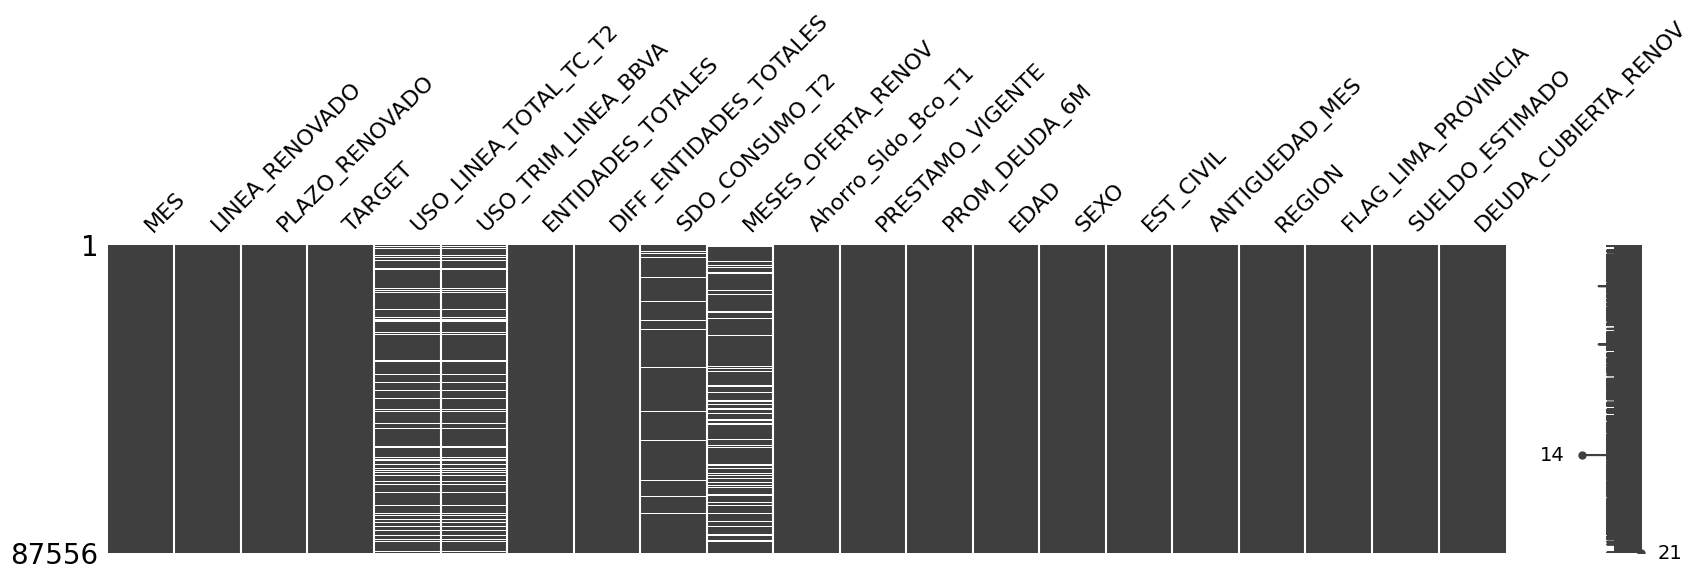

In [11]:
# Ver la correlacion o relación de los vacios
msno.matrix(df, figsize=(20, 4))

#Se observa correlacion de NULOS entre las variables: USO_LINEA_TOTAL_TC_T2 & USO_TRIM_LINEA_BBVA

In [12]:
#Comprobacion de correlacion observado con los valores NULOS
df[['USO_LINEA_TOTAL_TC_T2','USO_TRIM_LINEA_BBVA','SDO_CONSUMO_T2']].corr()

#Datos con correlacion lineal entre 'USO_LINEA_TOTAL_TC_T2' y'USO_TRIM_LINEA_BBVA' mayor al 50%
#Por lo que existe correlacion lineal entre ellos, sin embargo, no son linealmente DEPENDENDIENTES.

#Datos de SDO_CONSUMO_T2 sin alta correlacion lineal con 'USO_LINEA_TOTAL_TC_T2' ni 'USO_TRIM_LINEA_BBVA'.

,USO_LINEA_TOTAL_TC_T2,USO_TRIM_LINEA_BBVA,SDO_CONSUMO_T2
USO_LINEA_TOTAL_TC_T2,1.0000,0.5782,0.2496
USO_TRIM_LINEA_BBVA,0.5782,1.0000,0.2357
SDO_CONSUMO_T2,0.2496,0.2357,1.0000


In [13]:
#Confirmacion de cantidad de nulos entre 'USO_LINEA_TOTAL_TC_T2' y 'USO_TRIM_LINEA_BBVA
print(f'Total de USO_LINEA_TOTAL_TC_T2 nulos:\t{df['USO_LINEA_TOTAL_TC_T2'].isna().sum()}')
print(f'Total de USO_TRIM_LINEA_BBVA nulos:\t{df['USO_TRIM_LINEA_BBVA'].isna().sum()}')
print('Misma cantidad de nulos entre USO_LINEA_TOTAL_TC_T2 y USO_TRIM_LINEA_BBVA') if (df['USO_LINEA_TOTAL_TC_T2'].isna().sum()==df['USO_TRIM_LINEA_BBVA'].isna().sum()) else print('Diferente cantidad de nulos')

#Se puede deducir que los valores NULOS de ambas variables representan CLIENTES SIN LINEA
#Por lo que al imputar los nulos se deben de representar con un VALOR UNICO que represente CLIENTES SIN LINEA.

Total de USO_LINEA_TOTAL_TC_T2 nulos:	19192
Total de USO_TRIM_LINEA_BBVA nulos:	19192
Misma cantidad de nulos entre USO_LINEA_TOTAL_TC_T2 y USO_TRIM_LINEA_BBVA


In [14]:
#Revision de dependencia de nulos de SDO_CONSUMO_T2 con los valores nulos y ceros de USO_LINEA_TOTAL_TC_T2 y USO_TRIM_LINEA_BBVA
total_sdanull_usolinea_zero=df.loc[df['USO_LINEA_TOTAL_TC_T2'] == 0, 'SDO_CONSUMO_T2'].isna().sum()
total_sdanull_usolinea_null=df.loc[df['USO_LINEA_TOTAL_TC_T2'].isna(), 'SDO_CONSUMO_T2'].isna().sum()
total_sdanull_usolinea_conditional=total_sdanull_usolinea_zero+total_sdanull_usolinea_null

print(f'\nTotal de SDO_CONSUMO_T2 nulos:\t{df['SDO_CONSUMO_T2'].isna().sum()}')

print(f'Total de SDO_CONSUMO_T2 nulos para cada USO_LINEA_TOTAL_TC_T2 igual a CERO:\t{total_sdanull_usolinea_zero}')
print(f'Total de SDO_CONSUMO_T2 nulos para cada USO_LINEA_TOTAL_TC_T2 igual a NULO:\t{total_sdanull_usolinea_null}')
print(f'Sumatorio total de valores SDO_CONSUMO_T2 condicionados a USO_LINEA_TOTAL_TC_T2 igual a cero o nulo: {total_sdanull_usolinea_conditional}\n')

print('SDO_CONSUMO_T2 NULOS condicionado a USO_LINEA_TOTAL_TC_T2 iguales CEROS o NULOS') if (df['SDO_CONSUMO_T2'].isna().sum()==total_sdanull_usolinea_conditional) else print('SDO_CONSUMO_T2 no condicionado')
# Se observa que los valores nulos de SDO_CONSUMO_T2 solo se presentan cuando los valores de USO_LINEA_TOTAL_TC_T2 son CEROS o NULOS



Total de SDO_CONSUMO_T2 nulos:	5186
Total de SDO_CONSUMO_T2 nulos para cada USO_LINEA_TOTAL_TC_T2 igual a CERO:	2219
Total de SDO_CONSUMO_T2 nulos para cada USO_LINEA_TOTAL_TC_T2 igual a NULO:	2967
Sumatorio total de valores SDO_CONSUMO_T2 condicionados a USO_LINEA_TOTAL_TC_T2 igual a cero o nulo: 5186

SDO_CONSUMO_T2 NULOS condicionado a USO_LINEA_TOTAL_TC_T2 iguales CEROS o NULOS


### **Analisis de Variables Numericas | Cuantitativas**

* Graficas de histogramas y boxplots
* Analisis de correlacion
* Analisis de calidad de los datos numericos

**16** Variables de ***20*** (Sin contar la variable TARGET)

* MES
* LINEA_RENOVADO
* PLAZO_RENOVADO
* ENTIDADES_TOTALES
* DIFF_ENTIDADES_TOTALES
* EDAD
* ANTIGUEDAD_MES

* Ahorro_Sldo_Bco_T1
* PRESTAMO_VIGENTE
* PROM_DEUDA_6M
* SUELDO_ESTIMADO
* DEUDA_CUBIERTA_RENOV
* USO_LINEA_TOTAL_TC_T2
* USO_TRIM_LINEA_BBVA
* SDO_CONSUMO_T2
* MESES_OFERTA_RENOV

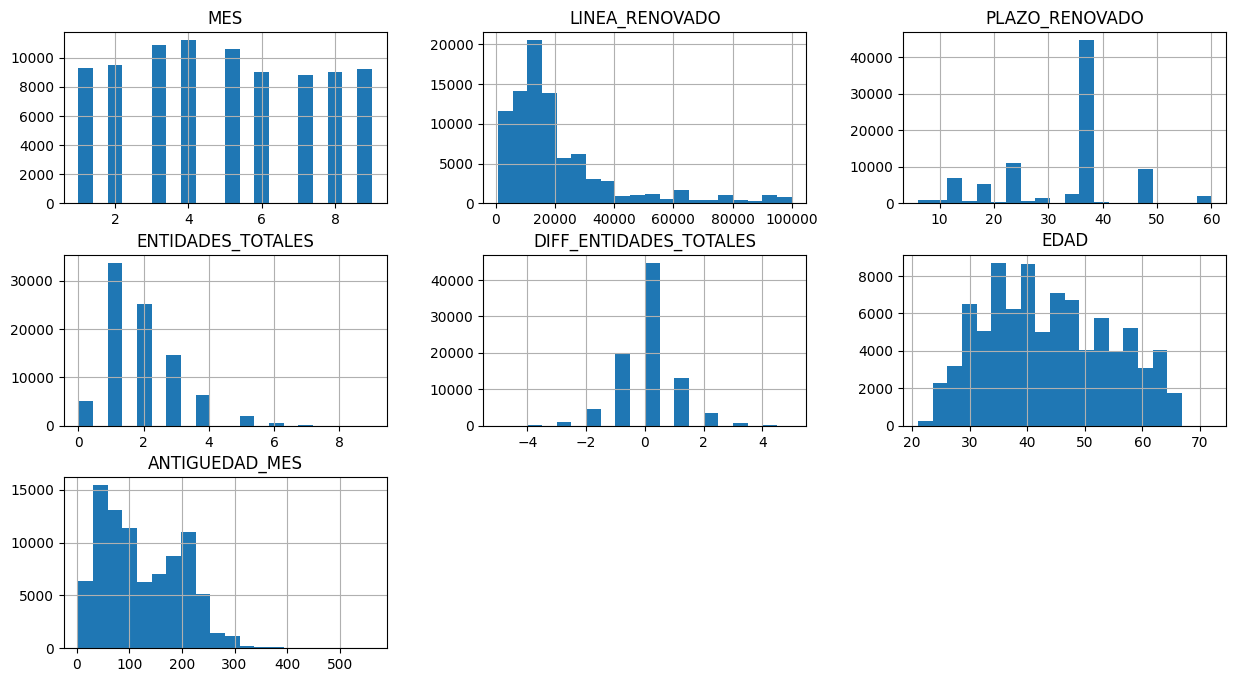

In [15]:
# Graficar histograma de las variables numericas NO BINARIAS, SIN NULOS:
# Se Omite Ahorro_Sldo_Bco_T1, PRESTAMO_VIGENTE, PROM_DEUDA_6M, SUELDO_ESTIMADO, DEUDA_CUBIERTA_RENOV por salto drastico en sus datos interquartiles
df[['MES','LINEA_RENOVADO','PLAZO_RENOVADO','ENTIDADES_TOTALES','DIFF_ENTIDADES_TOTALES','EDAD','ANTIGUEDAD_MES']].hist(bins=20,figsize=(15,8))
plt.show()

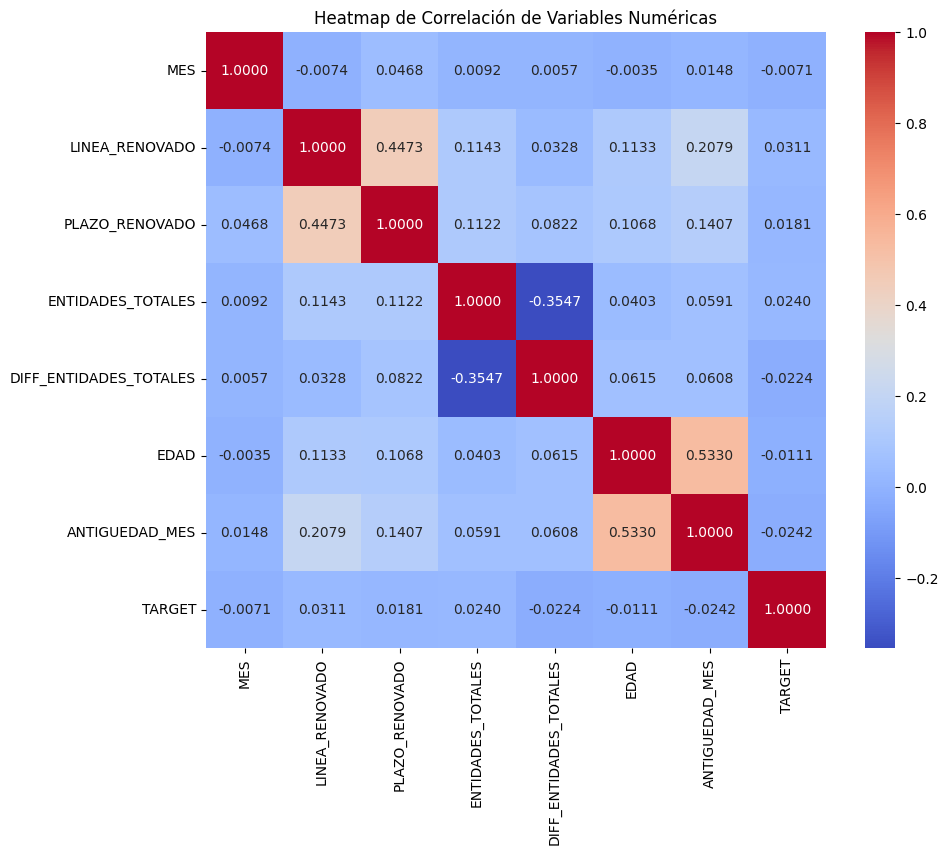

In [16]:
# Analisis de correlacion con variables numericas NO BINARIAS, SIN NULOS del histograma.
correlation_matrix=df[['MES','LINEA_RENOVADO','PLAZO_RENOVADO','ENTIDADES_TOTALES','DIFF_ENTIDADES_TOTALES','EDAD','ANTIGUEDAD_MES','TARGET']].corr()

#No se observa correlacion lineal con respecto a la variable TARGET (Corr > 10%)

#Grafica de mapa de calor del matriz de correlacion
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".4f")
plt.title('Heatmap de Correlación de Variables Numéricas')
plt.show()

# Se observa alta correlacion entre:
# PLAZO_RENOVADO & LINEA_RENOVADO
# EDAD & ANTIGUEDAD_MES

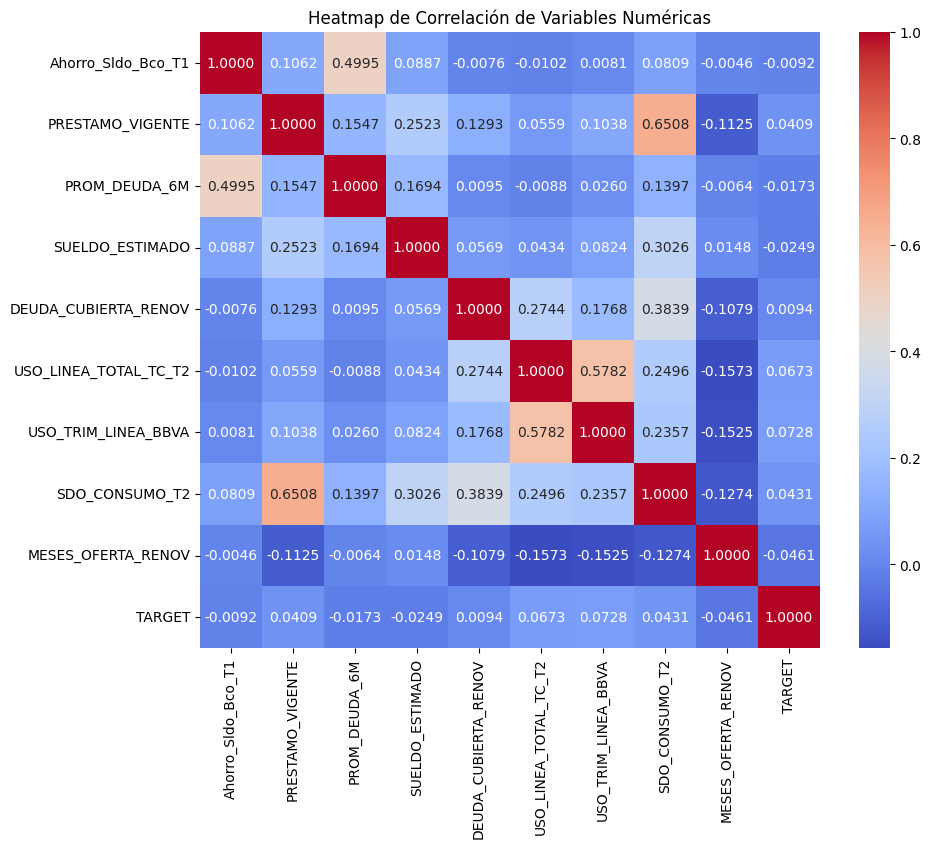

In [17]:
# Analisis de correlacion con variables numericas NO BINARIAS, CON NULOS y saltos Intercuartílico drasticos.
correlation_matrix=df[['Ahorro_Sldo_Bco_T1','PRESTAMO_VIGENTE','PROM_DEUDA_6M','SUELDO_ESTIMADO','DEUDA_CUBIERTA_RENOV','USO_LINEA_TOTAL_TC_T2','USO_TRIM_LINEA_BBVA','SDO_CONSUMO_T2','MESES_OFERTA_RENOV','TARGET']].corr()

#No se observa correlacion lineal con respecto a la variable TARGET (Corr > 10%)

#Grafica de mapa de calor del matriz de correlacion
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".4f")
plt.title('Heatmap de Correlación de Variables Numéricas')
plt.show()

# Se observa alta correlacion entre:
# PROM_DEUDA_6M & Ahorro_Sldo_Bco_T1
# PRESTAMO_VIGENTE & SDO_CONSUMO_T2
# USO_TRIM_LINEA_BBVA & USO_LINEA_TOTAL_TC_T2

<Axes: xlabel='MES', ylabel='EDAD'>

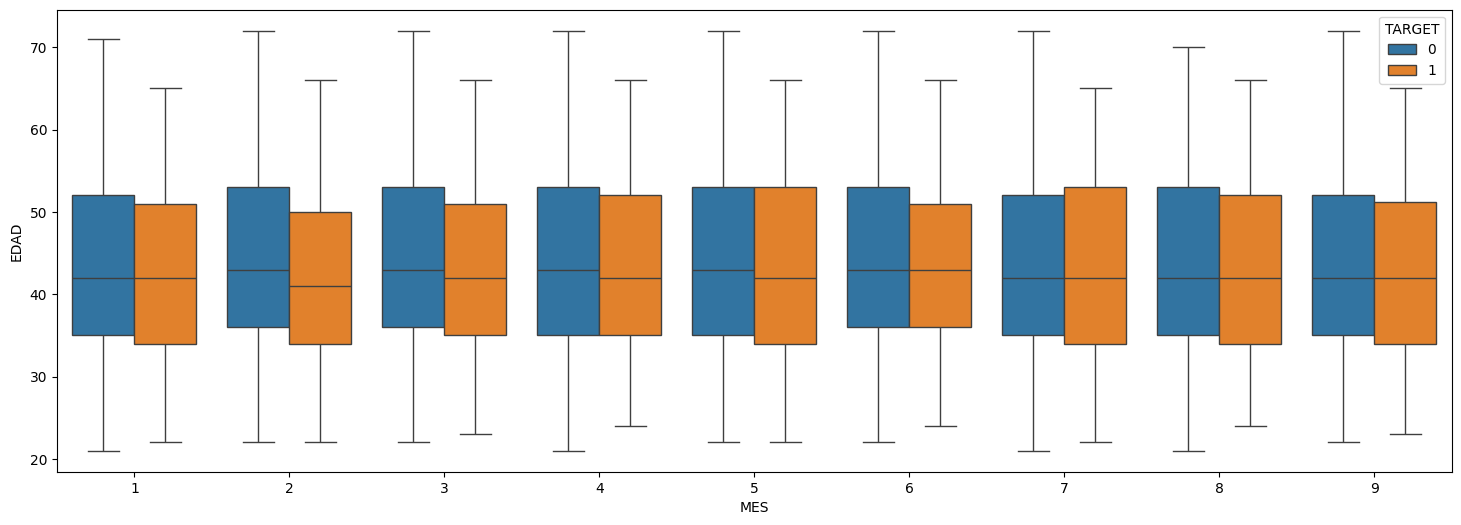

In [18]:
# BoxPlot para Visualización de la Separabilidad segmentadas por el TARGET - MES vs EDAD
plt.figure(figsize=(18,6))
sns.boxplot(x="MES",y="EDAD", hue="TARGET", data=df)

#Se muestra ESTACIONARIDAD EN LOS DATOS

<Axes: xlabel='MES', ylabel='LINEA_RENOVADO'>

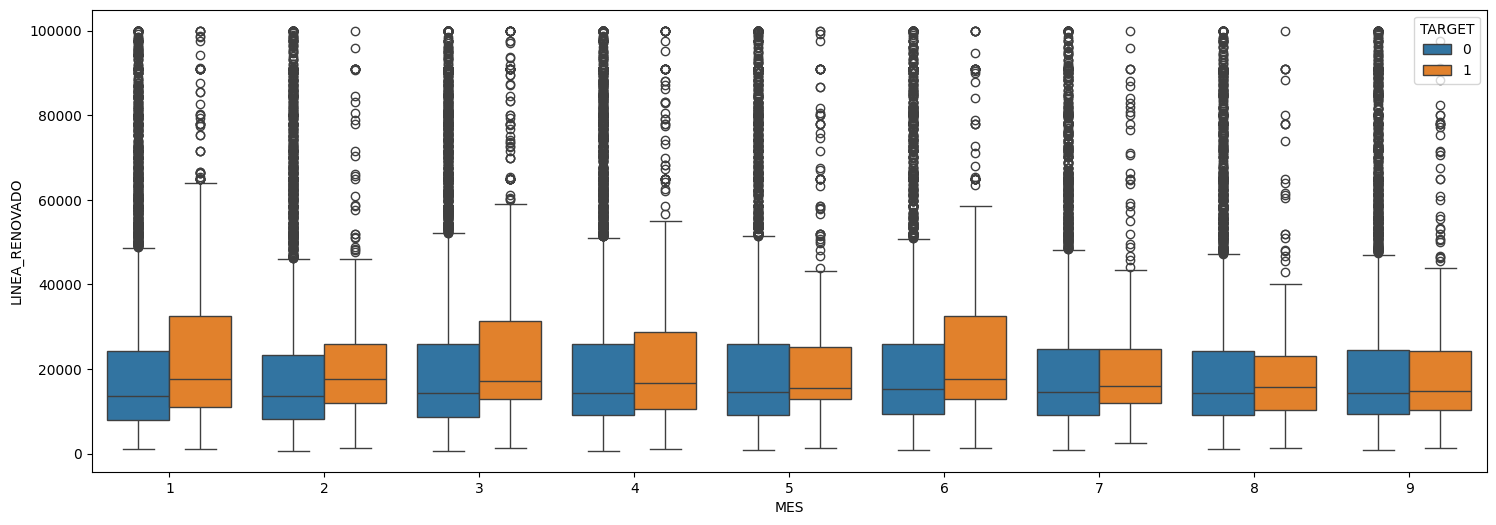

In [19]:
# BoxPlot para Visualización de la Separabilidad segmentadas por el TARGET - MES vs LINEA_RENOVADO
plt.figure(figsize=(18,6))
sns.boxplot(x="MES",y="LINEA_RENOVADO", hue="TARGET", data=df)

#Se muestra alta dispersion de los datos y valores outliers

<Axes: xlabel='MES', ylabel='USO_LINEA_TOTAL_TC_T2'>

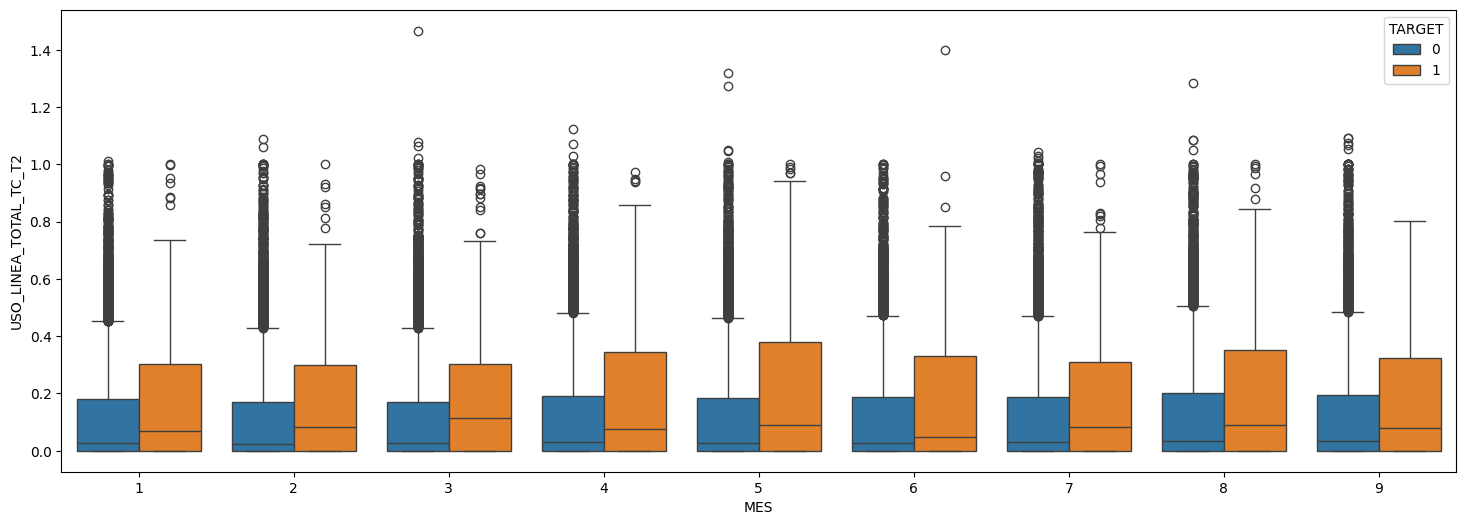

In [20]:
# BoxPlot para Visualización de la Separabilidad segmentadas por el TARGET - MES vs USO_LINEA_TOTAL_TC_T2
plt.figure(figsize=(18,6))
sns.boxplot(x="MES",y="USO_LINEA_TOTAL_TC_T2", hue="TARGET", data=df)

#Se muestra alta dispersion de los datos y valores outliers

<Axes: xlabel='MES', ylabel='USO_TRIM_LINEA_BBVA'>

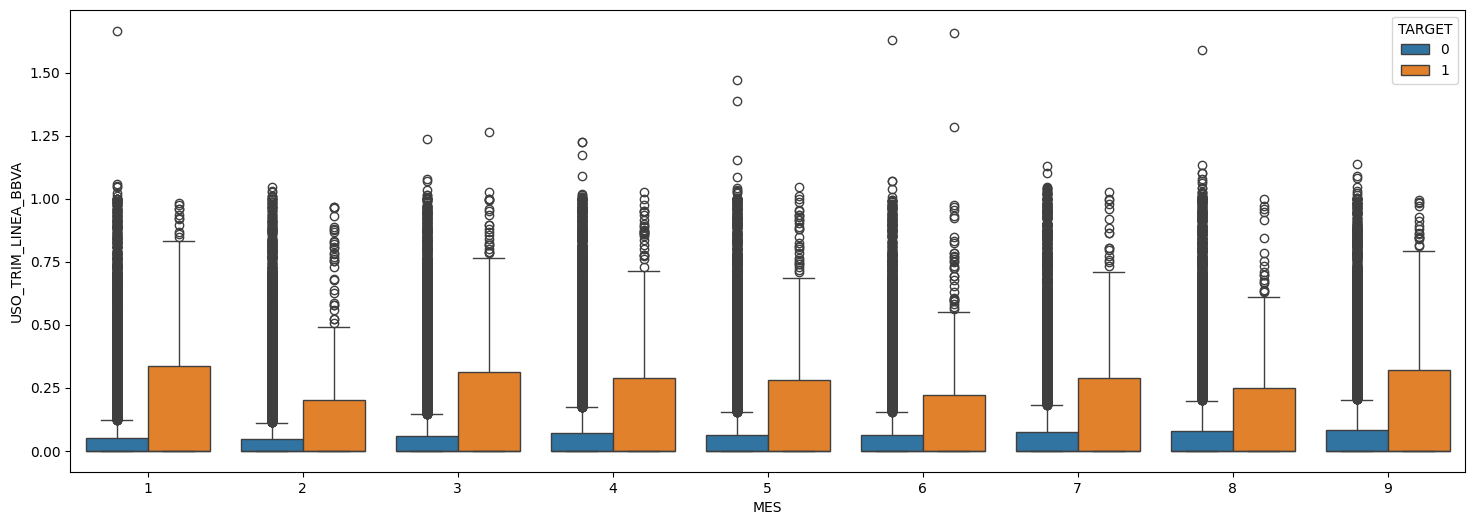

In [21]:
# BoxPlot para Visualización de la Separabilidad segmentadas por el TARGET - MES vs USO_TRIM_LINEA_BBVA
plt.figure(figsize=(18,6))
sns.boxplot(x="MES",y="USO_TRIM_LINEA_BBVA", hue="TARGET", data=df)

#Se muestra alta dispersion de los datos y valores outliers

<Axes: xlabel='MES', ylabel='ENTIDADES_TOTALES'>

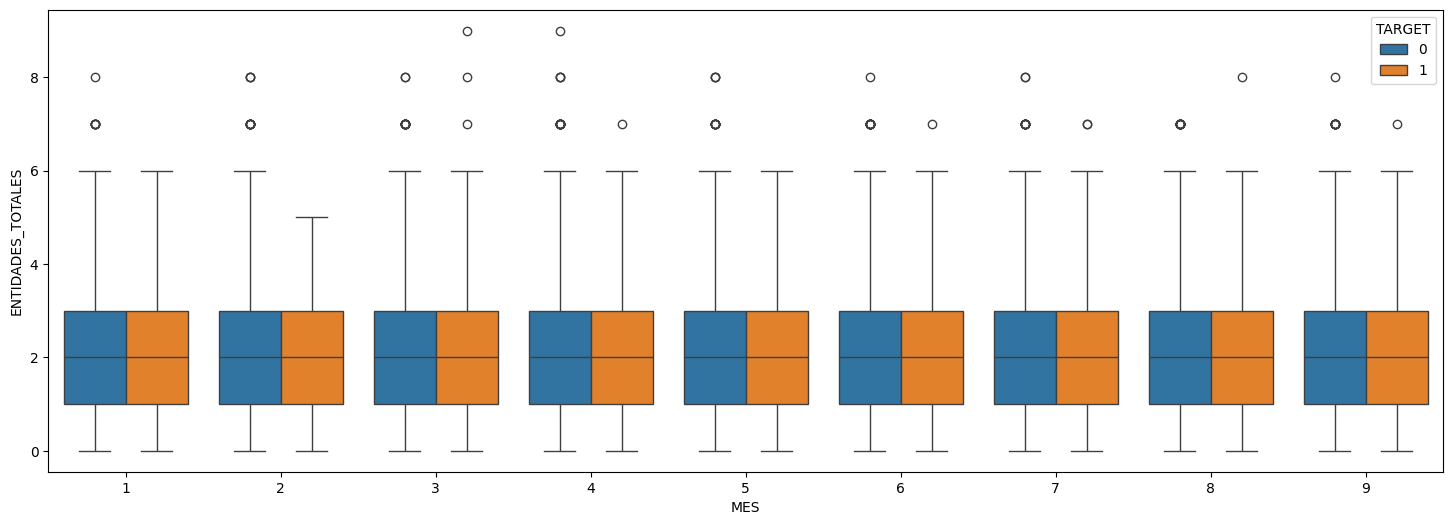

In [22]:
# BoxPlot para Visualización de la Separabilidad segmentadas por el TARGET - MES vs ENTIDADES_TOTALES
plt.figure(figsize=(18,6))
sns.boxplot(x="MES",y="ENTIDADES_TOTALES", hue="TARGET", data=df)

#Se muestra distribucion equitativa entre las medias por cada target y pocos valores outliers

<Axes: xlabel='MES', ylabel='DIFF_ENTIDADES_TOTALES'>

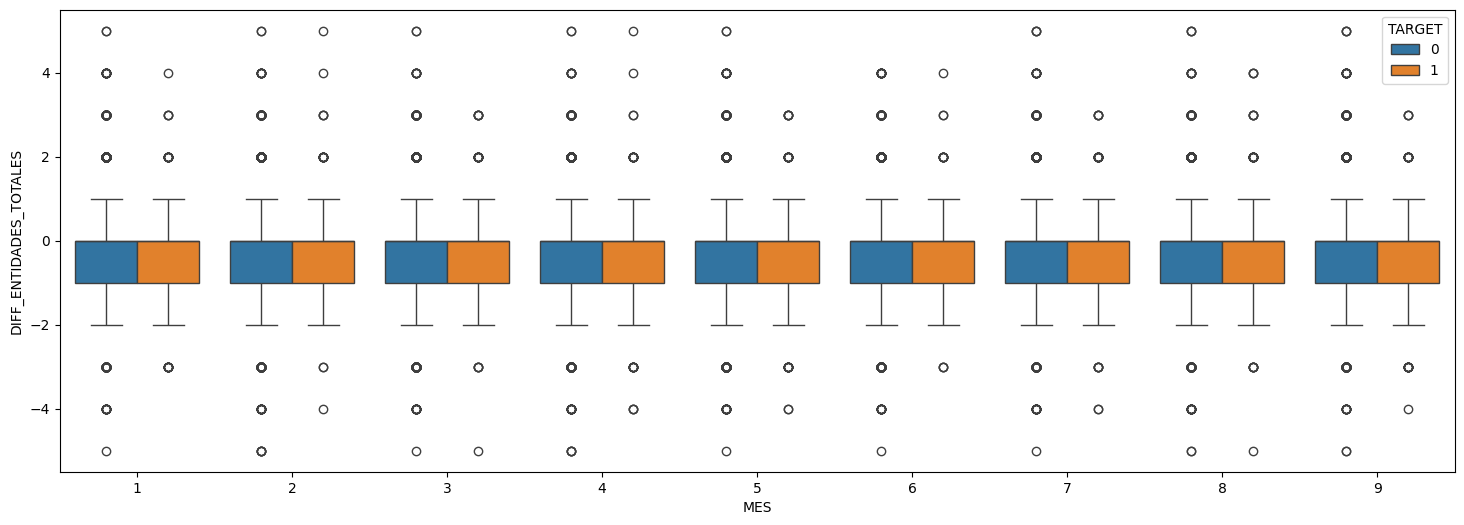

In [23]:
# BoxPlot para Visualización de la Separabilidad segmentadas por el TARGET - MES vs DIFF_ENTIDADES_TOTALES
plt.figure(figsize=(18,6))
sns.boxplot(x="MES",y="DIFF_ENTIDADES_TOTALES", hue="TARGET", data=df)

#Se muestran valores outliers

<Axes: xlabel='MES', ylabel='SDO_CONSUMO_T2'>

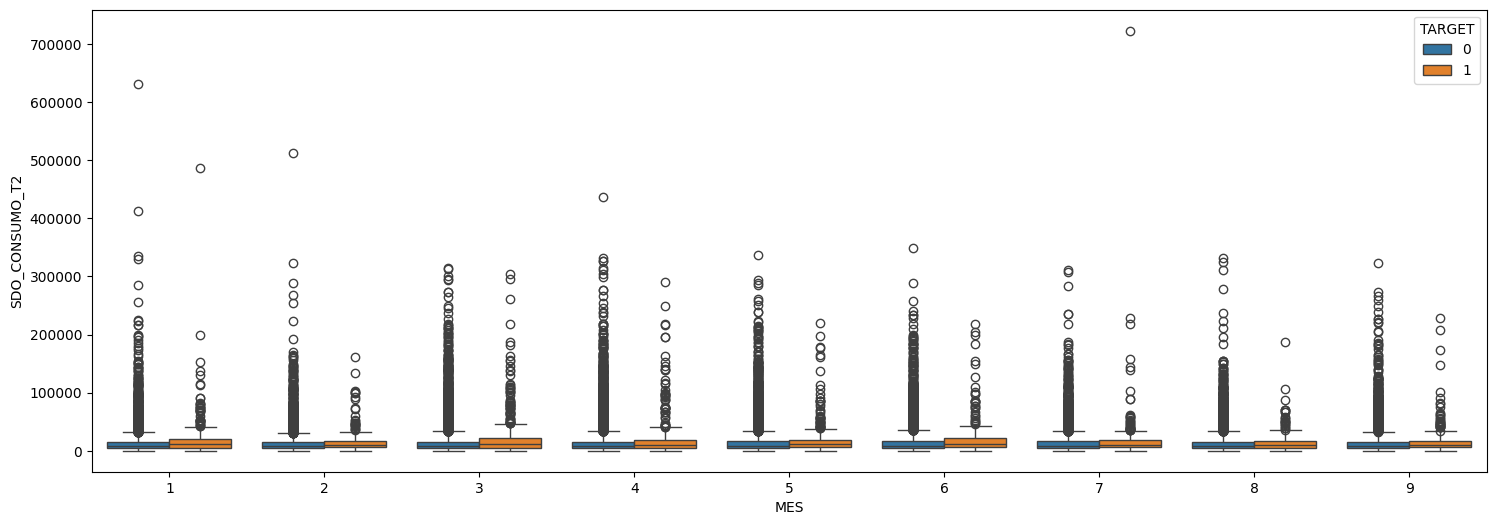

In [24]:
# BoxPlot para Visualización de la Separabilidad segmentadas por el TARGET - MES vs SDO_CONSUMO_T2
plt.figure(figsize=(18,6))
sns.boxplot(x="MES",y="SDO_CONSUMO_T2", hue="TARGET", data=df)

#Se muestra alta dispersion de los datos y valores outliers

In [25]:
#Datos estadisticas de SDO_CONSUMO_T2 por que se observa alta dispersion de los datos
print(df['SDO_CONSUMO_T2'].describe())

print(f'\nSe observa una diferencia entre la media y el promedio del: {((df['SDO_CONSUMO_T2'].mean())-df['SDO_CONSUMO_T2'].median())/100:.2f}%')
print(f'\nSe observa una diferencia entre la desviacion estandar y el promedio del: {((df['SDO_CONSUMO_T2'].std())-df['SDO_CONSUMO_T2'].mean())/100:.2f}%\n')

percentiles = [0.90, 0.95, 0.99, 0.995, 0.999]
print(f'Analisis de distribucion de percentiles:\n{df['SDO_CONSUMO_T2'].quantile(percentiles)}')

print(f'\nSe observan que hay una diferencia entre el percentil del 99% con respecto al 99.9% (el 1% de los clientes) de:\n{(df['SDO_CONSUMO_T2'].quantile(0.999))-(df['SDO_CONSUMO_T2'].quantile(0.99)):.2f}')
print(f'\nPresentando un valor de {(df['SDO_CONSUMO_T2'].quantile(0.999))/(df['SDO_CONSUMO_T2'].quantile(0.99)):.2f} entre el percentil 99.9 contra el 99.0')
print('\nPor lo que se concluye que existe un peso desproporcionado de los datos por clientes \"Outlier de Negocio\" existentes en los datos')

#Se debe topar los datos de SDO_CONSUMO_T2 con upper clip al percentil 0.99

count    82370.0000
mean     14385.1723
std      21570.0624
min          0.0000
25%       4102.6550
50%       8368.1450
75%      15786.3900
max     722781.0900
Name: SDO_CONSUMO_T2, dtype: float64

Se observa una diferencia entre la media y el promedio del: 60.17%

Se observa una diferencia entre la desviacion estandar y el promedio del: 71.85%

Analisis de distribucion de percentiles:
0.9000    30820.7910
0.9500    48501.9050
0.9900   107020.9124
0.9950   141815.2515
0.9990   224490.7919
Name: SDO_CONSUMO_T2, dtype: float64

Se observan que hay una diferencia entre el percentil del 99% con respecto al 99.9% (el 1% de los clientes) de:
117469.88

Presentando un valor de 2.10 entre el percentil 99.9 contra el 99.0

Por lo que se concluye que existe un peso desproporcionado de los datos por clientes "Outlier de Negocio" existentes en los datos


<Axes: xlabel='MES', ylabel='MESES_OFERTA_RENOV'>

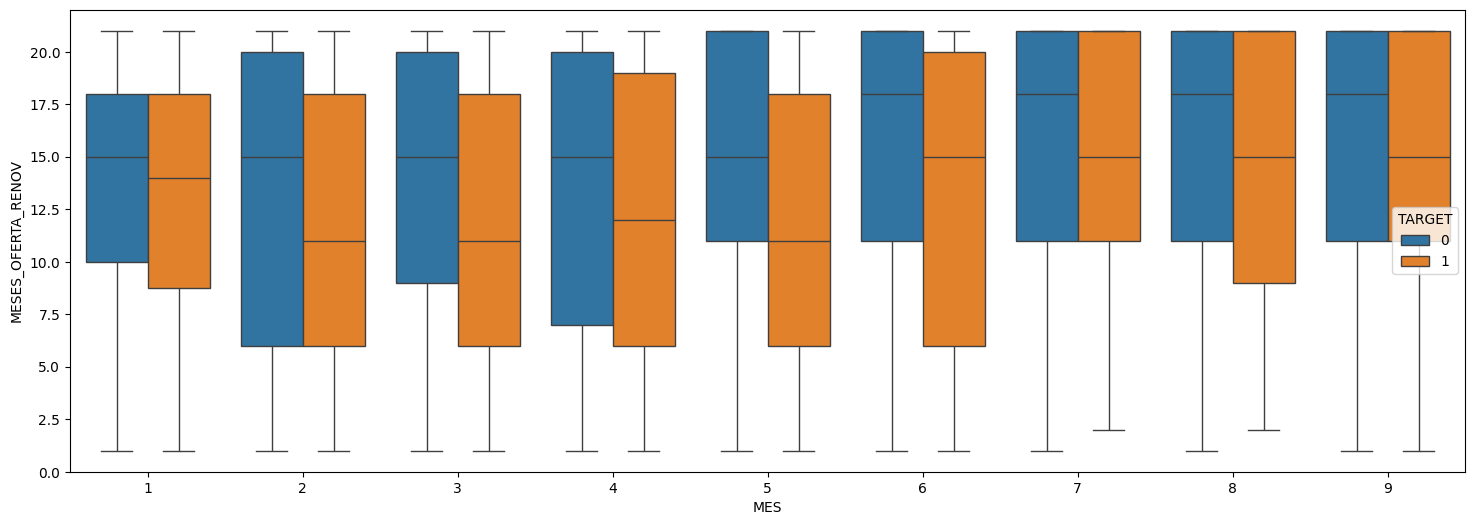

In [26]:
# BoxPlot para Visualización de la Separabilidad segmentadas por el TARGET - MES vs MESES_OFERTA_RENOV
plt.figure(figsize=(18,6))
sns.boxplot(x="MES",y="MESES_OFERTA_RENOV", hue="TARGET", data=df)

#Se muestra alta dispersion de los intercuartiles en diferentes meses

<Axes: xlabel='MES', ylabel='Ahorro_Sldo_Bco_T1'>

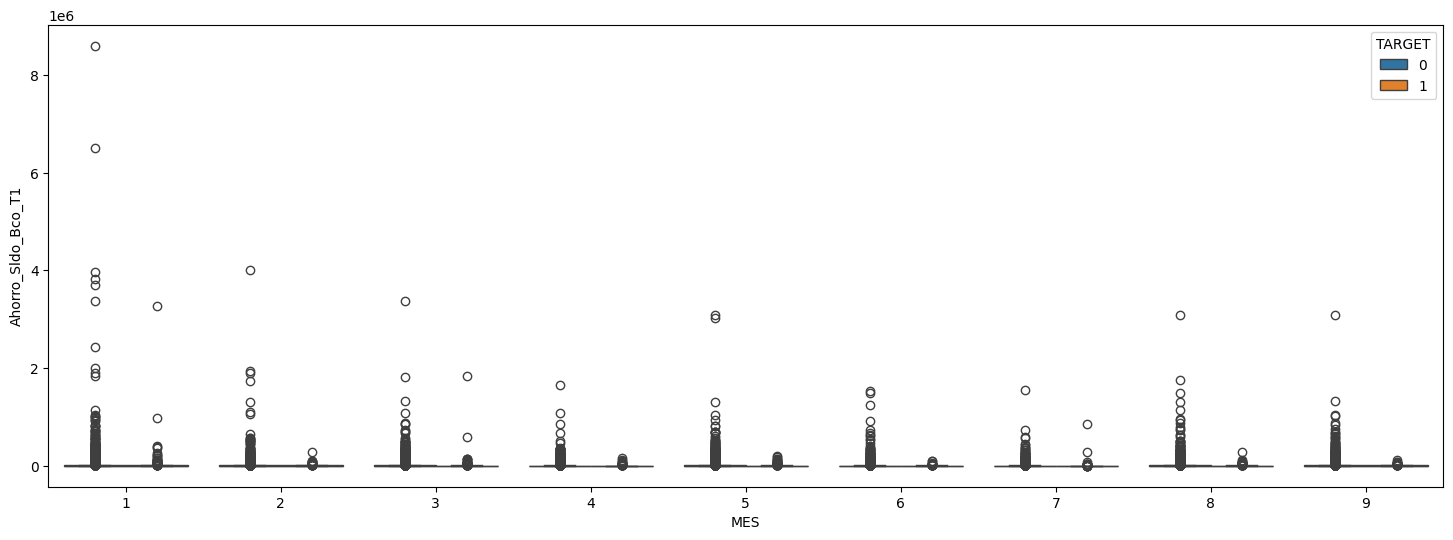

In [27]:
# BoxPlot para Visualización de la Separabilidad segmentadas por el TARGET - MES vs Ahorro_Sldo_Bco_T1
plt.figure(figsize=(18,6))
sns.boxplot(x="MES",y="Ahorro_Sldo_Bco_T1", hue="TARGET", data=df)
#Se muestra alta dispersion de los intercuartiles en diferentes meses

In [28]:
#Datos estadisticas de Ahorro_Sldo_Bco_T1 por que se observa alta dispersion de los datos
print(df['Ahorro_Sldo_Bco_T1'].describe())

print(f'\nSe observa una diferencia entre la media y el promedio del: {((df['Ahorro_Sldo_Bco_T1'].mean())-df['Ahorro_Sldo_Bco_T1'].median())/100:.2f}%')
print(f'\nSe observa una diferencia entre la desviacion estandar y el promedio del: {((df['Ahorro_Sldo_Bco_T1'].std())-df['Ahorro_Sldo_Bco_T1'].mean())/100:.2f}%\n')

percentiles = [0.90, 0.95, 0.99, 0.995, 0.999]
print(f'Analisis de distribucion de percentiles:\n{df['Ahorro_Sldo_Bco_T1'].quantile(percentiles)}')

print(f'\nSe observan que hay una diferencia entre el percentil del 99% con respecto al 99.9% (el 1% de los clientes) de:\n{(df['Ahorro_Sldo_Bco_T1'].quantile(0.999))-(df['Ahorro_Sldo_Bco_T1'].quantile(0.99)):.2f}')
print(f'\nPresentando un valor de {(df['Ahorro_Sldo_Bco_T1'].quantile(0.999))/(df['Ahorro_Sldo_Bco_T1'].quantile(0.99)):.2f} entre el percentil 99.9 contra el 99.0')
print('\nPor lo que se concluye que existe un peso Desproporcionado de los datos por clientes \"Outlier de Negocio\" existentes en los datos.')

#Se debe topar los datos de Ahorro_Sldo_Bco_T1 con upper clip al percentil 0.99

count     87556.0000
mean      10805.5480
std       70683.6207
min        -979.0000
25%         147.0000
50%        1208.0000
75%        5246.0000
max     8597760.0000
Name: Ahorro_Sldo_Bco_T1, dtype: float64

Se observa una diferencia entre la media y el promedio del: 95.98%

Se observa una diferencia entre la desviacion estandar y el promedio del: 598.78%

Analisis de distribucion de percentiles:
0.9000    19411.5000
0.9500    41776.0000
0.9900   156260.0000
0.9950   252670.6750
0.9990   676583.0800
Name: Ahorro_Sldo_Bco_T1, dtype: float64

Se observan que hay una diferencia entre el percentil del 99% con respecto al 99.9% (el 1% de los clientes) de:
520323.08

Presentando un valor de 4.33 entre el percentil 99.9 contra el 99.0

Por lo que se concluye que existe un peso Desproporcionado de los datos por clientes "Outlier de Negocio" existentes en los datos.


<Axes: xlabel='MES', ylabel='PRESTAMO_VIGENTE'>

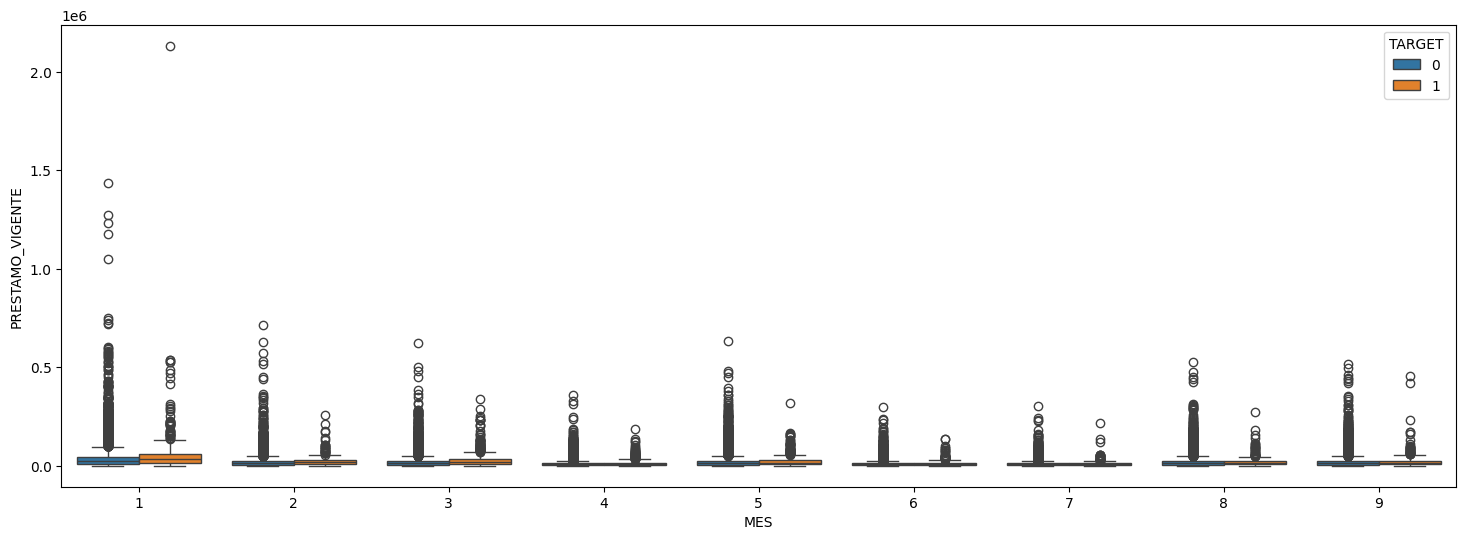

In [29]:
# BoxPlot para Visualización de la Separabilidad segmentadas por el TARGET - MES vs PRESTAMO_VIGENTE
plt.figure(figsize=(18,6))
sns.boxplot(x="MES",y="PRESTAMO_VIGENTE", hue="TARGET", data=df)

#Se muestra alta dispersion de los datos y valores outliers

In [30]:
#Datos estadisticas de PRESTAMO_VIGENTE por que se observa alta dispersion de los datos
print(df['PRESTAMO_VIGENTE'].describe())

print(f'\nSe observa una diferencia entre la media y el promedio del: {((df['PRESTAMO_VIGENTE'].mean())-df['PRESTAMO_VIGENTE'].median())/100:.2f}%')
print(f'\nSe observa una diferencia entre la desviacion estandar y el promedio del: {((df['PRESTAMO_VIGENTE'].std())-df['PRESTAMO_VIGENTE'].mean())/100:.2f}%\n')

percentiles = [0.90, 0.95, 0.99, 0.995, 0.999]
print(f'Analisis de distribucion de percentiles:\n{df['PRESTAMO_VIGENTE'].quantile(percentiles)}')

print(f'\nSe observan que hay una diferencia entre el percentil del 99% con respecto al 99.9% (el 1% de los clientes) de:\n{(df['PRESTAMO_VIGENTE'].quantile(0.999))-(df['PRESTAMO_VIGENTE'].quantile(0.99)):.2f}')
print(f'\nPresentando un valor de {(df['PRESTAMO_VIGENTE'].quantile(0.999))/(df['PRESTAMO_VIGENTE'].quantile(0.99)):.2f} entre el percentil 99.9 contra el 99.0')
print('\nPor lo que se concluye que existe un peso desproporcionado de los datos por clientes \"Outlier de Negocio\" existentes en los datos')

#Se debe topar los datos de PRESTAMO_VIGENTE con upper clip al percentil 0.99

count     87556.0000
mean      19673.2931
std       35031.9480
min         -98.0000
25%        3954.0000
50%       10162.0000
75%       21453.0000
max     2132740.0000
Name: PRESTAMO_VIGENTE, dtype: float64

Se observa una diferencia entre la media y el promedio del: 95.11%

Se observa una diferencia entre la desviacion estandar y el promedio del: 153.59%

Analisis de distribucion de percentiles:
0.9000    44414.0000
0.9500    71852.0000
0.9900   156130.8000
0.9950   207542.8500
0.9990   379692.4500
Name: PRESTAMO_VIGENTE, dtype: float64

Se observan que hay una diferencia entre el percentil del 99% con respecto al 99.9% (el 1% de los clientes) de:
223561.65

Presentando un valor de 2.43 entre el percentil 99.9 contra el 99.0

Por lo que se concluye que existe un peso desproporcionado de los datos por clientes "Outlier de Negocio" existentes en los datos


<Axes: xlabel='MES', ylabel='PROM_DEUDA_6M'>

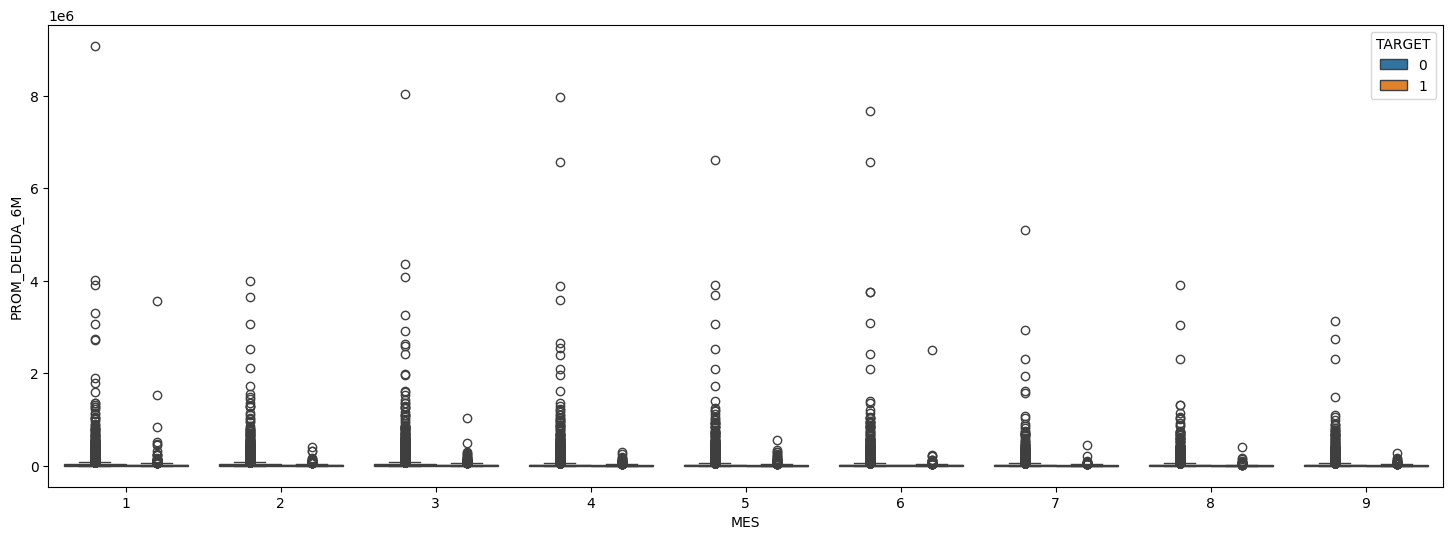

In [31]:
# BoxPlot para Visualización de la Separabilidad segmentadas por el TARGET - MES vs PROM_DEUDA_6M
plt.figure(figsize=(18,6))
sns.boxplot(x="MES",y="PROM_DEUDA_6M", hue="TARGET", data=df)

#Se muestra MUY alta dispersion de los datos y valores outliers

In [32]:
#Datos estadisticas de PROM_DEUDA_6M por que se observa alta dispersion de los datos
print(df['PROM_DEUDA_6M'].describe())

print(f'\nSe observa una diferencia entre la media y el promedio del: {((df['PROM_DEUDA_6M'].mean())-df['PROM_DEUDA_6M'].median())/100:.2f}%')
print(f'\nSe observa una diferencia entre la desviacion estandar y el promedio del: {((df['PROM_DEUDA_6M'].std())-df['PROM_DEUDA_6M'].mean())/100:.2f}%\n')

percentiles = [0.90, 0.95, 0.99, 0.995, 0.999]
print(f'Analisis de distribucion de percentiles:\n{df['PROM_DEUDA_6M'].quantile(percentiles)}')

print(f'\nSe observan que hay una diferencia entre el percentil del 99% con respecto al 99.9% (el 1% de los clientes) de:\n{(df['PROM_DEUDA_6M'].quantile(0.999))-(df['PROM_DEUDA_6M'].quantile(0.99)):.2f}')
print(f'\nPresentando un valor de {(df['PROM_DEUDA_6M'].quantile(0.999))/(df['PROM_DEUDA_6M'].quantile(0.99)):.2f} entre el percentil 99.9 contra el 99.0')
print('\nPor lo que se concluye que existe un peso desproporcionado de los datos por clientes \"Outlier de Negocio\" existentes en los datos')

#Se debe topar los datos de PROM_DEUDA_6M con upper clip al percentil 0.99

count     87556.0000
mean      28746.0811
std      122550.0946
min       -1123.8000
25%        1002.7917
50%        6363.1667
75%       23710.3333
max     9077797.0000
Name: PROM_DEUDA_6M, dtype: float64

Se observa una diferencia entre la media y el promedio del: 223.83%

Se observa una diferencia entre la desviacion estandar y el promedio del: 938.04%

Analisis de distribucion de percentiles:
0.9000     60934.6667
0.9500    108259.2500
0.9900    331911.6833
0.9950    492011.2000
0.9990   1284781.4068
Name: PROM_DEUDA_6M, dtype: float64

Se observan que hay una diferencia entre el percentil del 99% con respecto al 99.9% (el 1% de los clientes) de:
952869.72

Presentando un valor de 3.87 entre el percentil 99.9 contra el 99.0

Por lo que se concluye que existe un peso desproporcionado de los datos por clientes "Outlier de Negocio" existentes en los datos


<Axes: xlabel='MES', ylabel='ANTIGUEDAD_MES'>

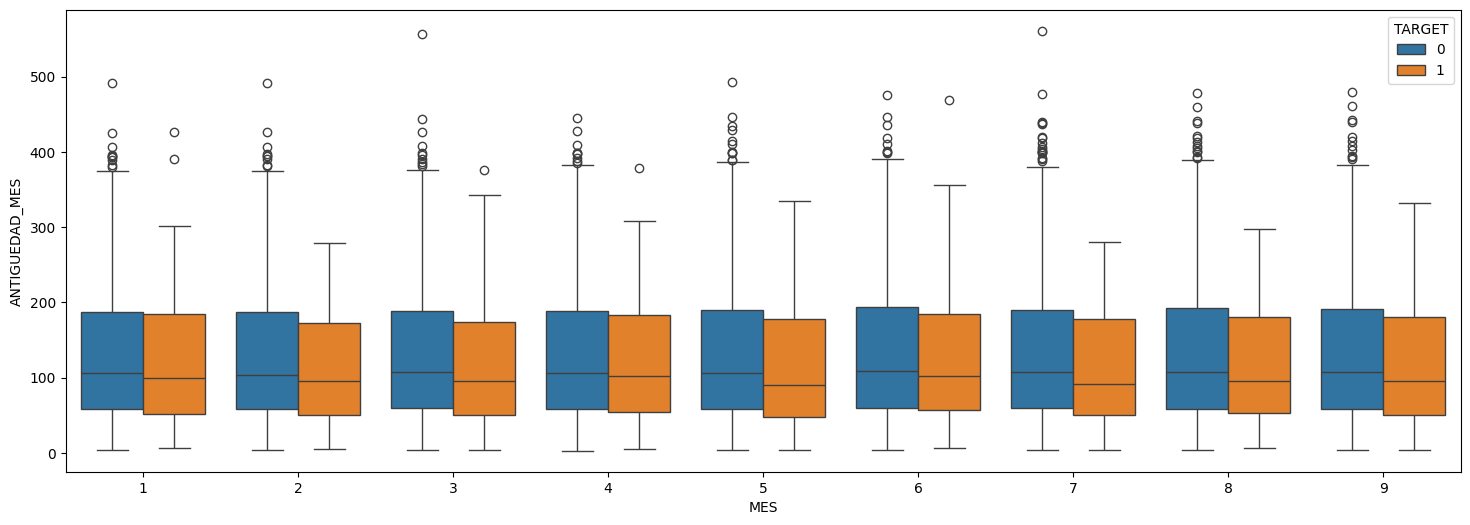

In [33]:
# BoxPlot para Visualización de la Separabilidad segmentadas por el TARGET - MES vs ANTIGUEDAD_MES
plt.figure(figsize=(18,6))
sns.boxplot(x="MES",y="ANTIGUEDAD_MES", hue="TARGET", data=df)

#Se muestra algunos valores outliers

<Axes: xlabel='MES', ylabel='SUELDO_ESTIMADO'>

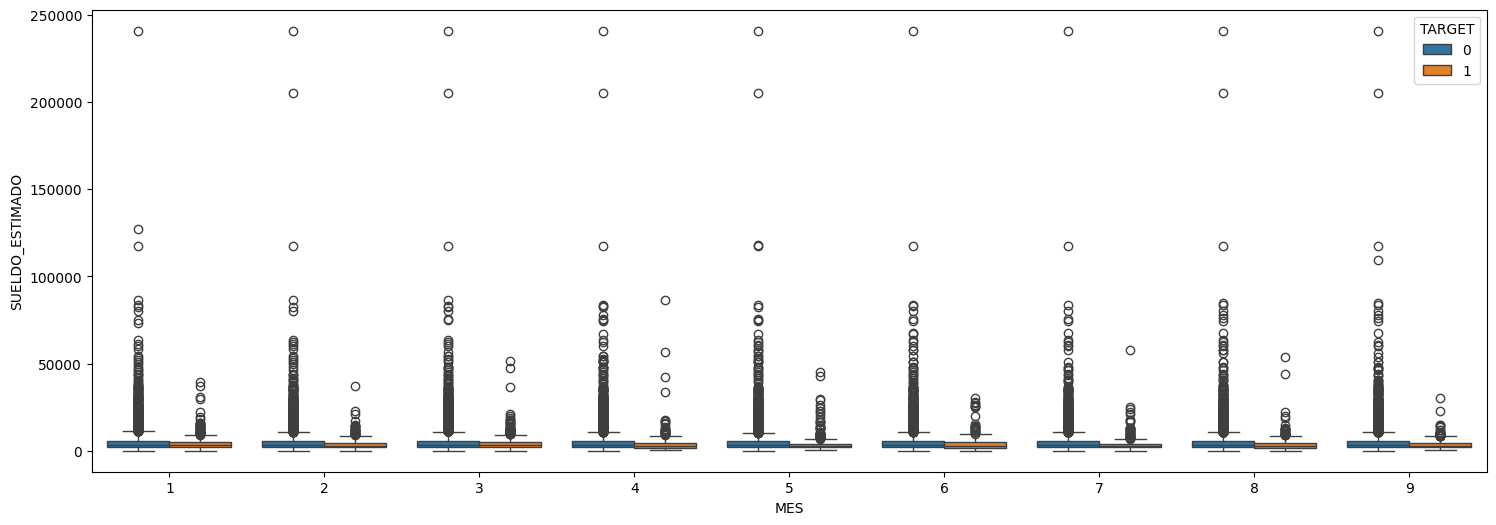

In [34]:
# BoxPlot para Visualización de la Separabilidad segmentadas por el TARGET - MES vs SUELDO_ESTIMADO
plt.figure(figsize=(18,6))
sns.boxplot(x="MES",y="SUELDO_ESTIMADO", hue="TARGET", data=df)

#Se muestra MUY alta dispersion de los datos y valores outliers

In [35]:
#Datos estadisticas de SUELDO_ESTIMADO por que se observa alta dispersion de los datos
print(df['SUELDO_ESTIMADO'].describe())

print(f'\nSe observa una diferencia entre la media y el promedio del: {((df['SUELDO_ESTIMADO'].mean())-df['SUELDO_ESTIMADO'].median())/100:.2f}%')
print(f'\nSe observa una diferencia entre la desviacion estandar y el promedio del: {((df['SUELDO_ESTIMADO'].std())-df['SUELDO_ESTIMADO'].mean())/100:.2f}%\n')

percentiles = [0.90, 0.95, 0.99, 0.995, 0.999]
print(f'Analisis de distribucion de percentiles:\n{df['SUELDO_ESTIMADO'].quantile(percentiles)}')

print(f'\nSe observan que hay una diferencia entre el percentil del 99% con respecto al 99.9% (el 1% de los clientes) de:\n{(df['SUELDO_ESTIMADO'].quantile(0.999))-(df['SUELDO_ESTIMADO'].quantile(0.99)):.2f}')
print(f'\nPresentando un valor de {(df['SUELDO_ESTIMADO'].quantile(0.999))/(df['SUELDO_ESTIMADO'].quantile(0.99)):.2f} entre el percentil 99.9 contra el 99.0')
print('\nPor lo que se concluye que existe un peso desproporcionado de los datos por clientes \"Outlier de Negocio\" existentes en los datos')

#Se debe topar los datos de SUELDO_ESTIMADO con upper clip al percentil 0.99

count    87519.0000
mean      4766.2873
std       6003.9198
min          0.0000
25%       2183.4900
50%       3178.1200
75%       5599.0000
max     240909.0000
Name: SUELDO_ESTIMADO, dtype: float64

Se observa una diferencia entre la media y el promedio del: 15.88%

Se observa una diferencia entre la desviacion estandar y el promedio del: 12.38%

Analisis de distribucion de percentiles:
0.9000    9320.0000
0.9500   12746.3000
0.9900   24750.0000
0.9950   32892.3700
0.9990   63273.0000
Name: SUELDO_ESTIMADO, dtype: float64

Se observan que hay una diferencia entre el percentil del 99% con respecto al 99.9% (el 1% de los clientes) de:
38523.00

Presentando un valor de 2.56 entre el percentil 99.9 contra el 99.0

Por lo que se concluye que existe un peso desproporcionado de los datos por clientes "Outlier de Negocio" existentes en los datos


<Axes: xlabel='MES', ylabel='DEUDA_CUBIERTA_RENOV'>

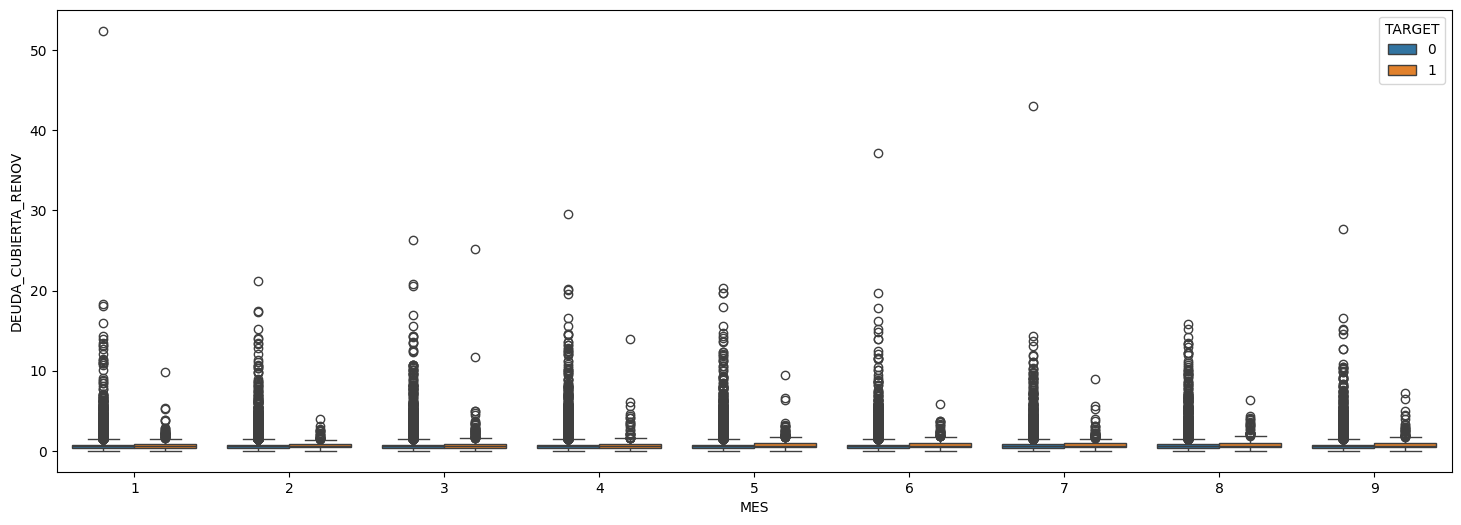

In [36]:
# BoxPlot para Visualización de la Separabilidad segmentadas por el TARGET - MES vs DEUDA_CUBIERTA_RENOV
plt.figure(figsize=(18,6))
sns.boxplot(x="MES",y="DEUDA_CUBIERTA_RENOV", hue="TARGET", data=df)

#Se muestra MUY alta dispersion de los datos y valores outliers

In [37]:
#Datos estadisticas de DEUDA_CUBIERTA_RENOV por que se observa alta dispersion de los datos
print(df['DEUDA_CUBIERTA_RENOV'].describe())

print(f'\nSe observa una diferencia entre la media y el promedio del: {((df['DEUDA_CUBIERTA_RENOV'].mean())-df['DEUDA_CUBIERTA_RENOV'].median())/100:.2f}%')
print(f'\nSe observa una diferencia entre la desviacion estandar y el promedio del: {((df['DEUDA_CUBIERTA_RENOV'].std())-df['DEUDA_CUBIERTA_RENOV'].mean())/100:.2f}%\n')

percentiles = [0.90, 0.95, 0.99, 0.995, 0.999]
print(f'Analisis de distribucion de percentiles:\n{df['DEUDA_CUBIERTA_RENOV'].quantile(percentiles)}')

print(f'\nSe observan que hay una diferencia entre el percentil del 99% con respecto al 99.9% (el 1% de los clientes) de:\n{(df['DEUDA_CUBIERTA_RENOV'].quantile(0.999))-(df['DEUDA_CUBIERTA_RENOV'].quantile(0.99)):.2f}')
print(f'\nPresentando un valor de {(df['DEUDA_CUBIERTA_RENOV'].quantile(0.999))/(df['DEUDA_CUBIERTA_RENOV'].quantile(0.99)):.2f} entre el percentil 99.9 contra el 99.0')
print('\nPor lo que se concluye que existe un peso desproporcionado de los datos por clientes \"Outlier de Negocio\" existentes en los datos')

#Se debe topar los datos de DEUDA_CUBIERTA_RENOV con upper clip al percentil 0.99

count   87556.0000
mean        0.7378
std         1.0388
min         0.0000
25%         0.3265
50%         0.5481
75%         0.7751
max        52.4342
Name: DEUDA_CUBIERTA_RENOV, dtype: float64

Se observa una diferencia entre la media y el promedio del: 0.00%

Se observa una diferencia entre la desviacion estandar y el promedio del: 0.00%

Analisis de distribucion de percentiles:
0.9000    1.3836
0.9500    2.1001
0.9900    4.7862
0.9950    6.7380
0.9990   12.3674
Name: DEUDA_CUBIERTA_RENOV, dtype: float64

Se observan que hay una diferencia entre el percentil del 99% con respecto al 99.9% (el 1% de los clientes) de:
7.58

Presentando un valor de 2.58 entre el percentil 99.9 contra el 99.0

Por lo que se concluye que existe un peso desproporcionado de los datos por clientes "Outlier de Negocio" existentes en los datos


In [38]:
#Analisis de valores negativos en datos numericos.
for label, content in df.items():
  if df[label].dtype != object and (df[label] < 0).sum()>0:
    print(f"\nTotal de numeros negativos en columna {label}:\t{(df[label] < 0).sum()}")
    print(df[df[label] < 0][label])

#Se encontró 5 variables numericas que presentan valores negativos, de los cuales 4 no hacen logica al negocio y se presentan menos del 1% del total de los datos:
#Ahorro_Sldo_Bco_T1, PRESTAMO_VIGENTE y  PROM_DEUDA_6M.

#Por lo estas variables deben toparse (Clipping) a 0.


Total de numeros negativos en columna DIFF_ENTIDADES_TOTALES:	25367
0       -1
2       -2
5       -2
6       -1
7       -2
        ..
87538   -1
87542   -1
87546   -2
87552   -1
87555   -1
Name: DIFF_ENTIDADES_TOTALES, Length: 25367, dtype: int64

Total de numeros negativos en columna Ahorro_Sldo_Bco_T1:	4
2260    -320
33925   -111
37627   -979
86295    -92
Name: Ahorro_Sldo_Bco_T1, dtype: int64

Total de numeros negativos en columna PRESTAMO_VIGENTE:	1
6771   -98
Name: PRESTAMO_VIGENTE, dtype: int64

Total de numeros negativos en columna PROM_DEUDA_6M:	2
22932   -1123.8000
29429    -934.8333
Name: PROM_DEUDA_6M, dtype: float64


### **Analisis de Variables Cualitativas**

**4** Variables de ***20*** (Sin contar la variable TARGET)
* SEXO
* EST_CIVIL
* REGION
* FLAG_LIMA_PROVINCIA (BINARIO)


In [39]:
print('Total de variables con datos NO NUMERICOS\n')
df.select_dtypes(include=['object']).info()
print('\n\n')
pd.concat([df.select_dtypes(include='object'), df['FLAG_LIMA_PROVINCIA']], axis=1).head(5)

Total de variables con datos NO NUMERICOS

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87556 entries, 0 to 87555
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   SEXO       87555 non-null  object
 1   EST_CIVIL  87555 non-null  object
 2   REGION     87538 non-null  object
dtypes: object(3)
memory usage: 2.0+ MB





,SEXO,EST_CIVIL,REGION,FLAG_LIMA_PROVINCIA
0,M,S,LIMA NORTE,1
1,M,S,LIMA ESTE,1
2,M,S,LIMA MODERNA,1
3,M,S,NORTE,0
4,M,C,NORTE,0


In [40]:
print(f'\nDistribucion de valores del atributo \"SEXO\"\n{df['SEXO'].value_counts(1)}\n')
print(f'\nDistribucion entre el atributo \"SEXO\" y el TARGET \n{df[['SEXO','TARGET']].groupby(by='SEXO').agg(['count','sum','mean'])}\n')

dist_target=df[['SEXO','TARGET']].groupby(by='SEXO').agg(['count','sum','mean'])
dist_target_goal=[dist_target.TARGET['mean'] > df['TARGET'].value_counts(1)[1]]

print(f'Atributos con distribucion por encima del promedio \"TARGET\": {df['TARGET'].value_counts(1)[1]} \n{dist_target_goal[0][dist_target_goal[0]]}')
#Total
# Hombres=2556 & Mujeres=936

#TOTAL DE TARGET IGUAL a 1 = 3492
#PROMEDIO DEL TARGET IGUAL a 1 = 0.0399 (3.9%)

#Atributo con Distribucion por encima del promedio del Target:
#M = 0.0416


Distribucion de valores del atributo "SEXO"
SEXO
M   0.7014
F   0.2986
Name: proportion, dtype: float64


Distribucion entre el atributo "SEXO" y el TARGET 
     TARGET             
      count   sum   mean
SEXO                    
F     26141   936 0.0358
M     61414  2556 0.0416

Atributos con distribucion por encima del promedio "TARGET": 0.0398830462789529 
SEXO
M    True
Name: mean, dtype: bool


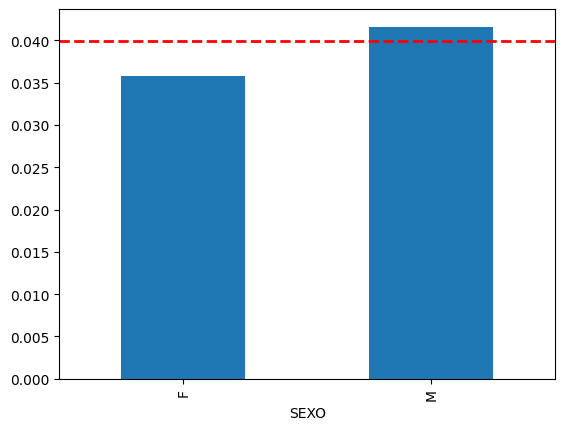

In [41]:
#Grafica de barra de la distribucion entre atributo y TARGET
data_plot=dist_target.TARGET['mean']
threshold=df['TARGET'].value_counts(1)[1]


plt = data_plot.plot(kind='bar')
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=2)

In [42]:
print(f'\nDistribucion de valores del atributo \"EST_CIVIL\"\n{df['EST_CIVIL'].value_counts(1)}\n')
print(f'\nDistribucion entre el atributo \"EST_CIVIL\" y el TARGET \n{df[['EST_CIVIL','TARGET']].groupby(by='EST_CIVIL').agg(['count','sum','mean'])}\n')

dist_target=df[['EST_CIVIL','TARGET']].groupby(by='EST_CIVIL').agg(['count','sum','mean'])
dist_target_goal=[dist_target.TARGET['mean'] > df['TARGET'].value_counts(1)[1]]

print(f'Atributos con distribucion por encima del promedio \"TARGET\": {df['TARGET'].value_counts(1)[1]} \n{dist_target_goal[0][dist_target_goal[0]]}')
#S: Soltaero
#C: Casado
#U: Union Libre
#D: Divorciado
#V: Viudo
#X & Y: ¿?

#TOTAL DE TARGET IGUAL a 1 = 3492
#PROMEDIO DEL TARGET IGUAL a 1 = 0.0399 (3.9%)

#Atributo con Distribucion por encima del promedio del Target:
#U = 0.0437
#D = 0.0422
#S = 0.0408


Distribucion de valores del atributo "EST_CIVIL"
EST_CIVIL
S   0.5064
C   0.4298
U   0.0314
D   0.0233
V   0.0090
Y   0.0001
X   0.0000
Name: proportion, dtype: float64


Distribucion entre el atributo "EST_CIVIL" y el TARGET 
          TARGET             
           count   sum   mean
EST_CIVIL                    
C          37631  1449 0.0385
D           2037    86 0.0422
S          44341  1811 0.0408
U           2749   120 0.0437
V            788    26 0.0330
X              1     0 0.0000
Y              8     0 0.0000

Atributos con distribucion por encima del promedio "TARGET": 0.0398830462789529 
EST_CIVIL
D    True
S    True
U    True
Name: mean, dtype: bool


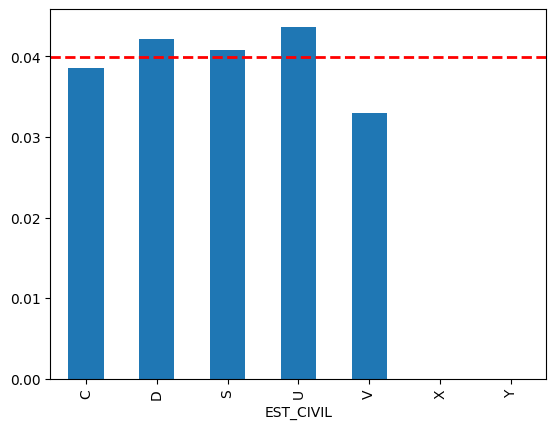

In [43]:
#Grafica de barra de la distribucion entre atributo y TARGET
data_plot=dist_target.TARGET['mean']
threshold=df['TARGET'].value_counts(1)[1]


plt = data_plot.plot(kind='bar')
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=2)

In [44]:
print(f'\nDistribucion de valores del atributo \"REGION\"\n{df['REGION'].value_counts(1)}\n')
print(f'\nDistribucion entre el atributo \"REGION\" y el TARGET \n{df[['REGION','TARGET']].groupby(by='REGION').agg(['count','sum','mean'])}\n')


dist_target=df[['REGION','TARGET']].groupby(by='REGION').agg(['count','sum','mean'])
dist_target_goal=[dist_target.TARGET['mean'] > df['TARGET'].value_counts(1)[1]]

print(f'Atributos con distribucion por encima del promedio \"TARGET\": {df['TARGET'].value_counts(1)[1]} \n{dist_target_goal[0][dist_target_goal[0]]}')
#TOTAL DE TARGET IGUAL a 1 = 3492
#PROMEDIO DEL TARGET IGUAL a 1 = 0.0399 (3.9%)

#Atributo con Distribucion por encima del promedio del Target:
# CENTRO = 0.0487
# LIMA BALNEARIO = 0.0467
# LIMA PROVINCIA = 0.0439
# OESTE = 0.0430
# ORIENTE = 0.0672
# SIERRA CENTRAL = 0.0523
# SUR = 0.0412


Distribucion de valores del atributo "REGION"
REGION
LIMA MODERNA     0.1581
CENTRO           0.1141
NORTE            0.1061
LIMA NORTE       0.1025
SUR              0.0954
LIMA ESTE        0.0944
LIMA SUR         0.0717
LIMA CENTRO      0.0622
ORIENTE          0.0484
CALLAO           0.0439
SIERRA CENTRAL   0.0350
LIMA PROVINCIA   0.0346
OESTE            0.0318
LIMA BALNEARIO   0.0017
Name: proportion, dtype: float64


Distribucion entre el atributo "REGION" y el TARGET 
               TARGET            
                count  sum   mean
REGION                           
CALLAO           3847  133 0.0346
CENTRO           9990  487 0.0487
LIMA BALNEARIO    150    7 0.0467
LIMA CENTRO      5443  203 0.0373
LIMA ESTE        8267  324 0.0392
LIMA MODERNA    13836  427 0.0309
LIMA NORTE       8973  302 0.0337
LIMA PROVINCIA   3029  133 0.0439
LIMA SUR         6274  229 0.0365
NORTE            9291  336 0.0362
OESTE            2788  120 0.0430
ORIENTE          4240  285 0.0672
SIERRA CENTR

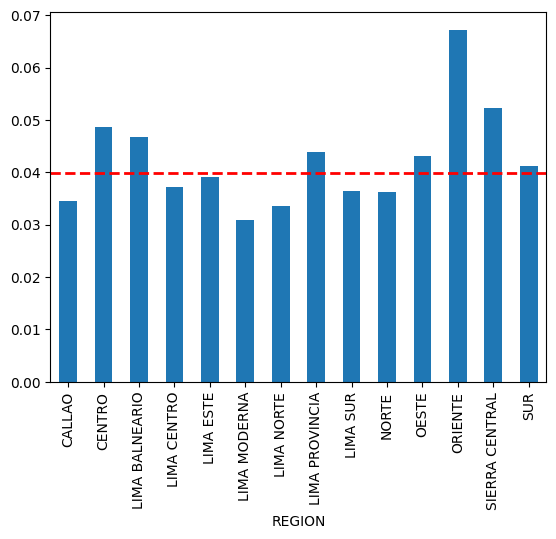

In [45]:
#Grafica de barra de la distribucion entre atributo y TARGET
data_plot=dist_target.TARGET['mean']
threshold=df['TARGET'].value_counts(1)[1]


plt = data_plot.plot(kind='bar')
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=2)

In [46]:
print(f'\nDistribucion de valores del atributo \"FLAG_LIMA_PROVINCIA\"\n{df['FLAG_LIMA_PROVINCIA'].value_counts(1)}\n')
print(f'\nDistribucion entre el atributo \"FLAG_LIMA_PROVINCIA\" y el TARGET \n{df[['FLAG_LIMA_PROVINCIA','TARGET']].groupby(by='FLAG_LIMA_PROVINCIA').agg(['count','sum','mean'])}\n')


dist_target=df[['FLAG_LIMA_PROVINCIA','TARGET']].groupby(by='FLAG_LIMA_PROVINCIA').agg(['count','sum','mean'])
dist_target_goal=[dist_target.TARGET['mean'] > df['TARGET'].value_counts(1)[1]]

print(f'Atributos con distribucion por encima del promedio \"TARGET\": {df['TARGET'].value_counts(1)[1]} \n{dist_target_goal[0][dist_target_goal[0]]}')


Distribucion de valores del atributo "FLAG_LIMA_PROVINCIA"
FLAG_LIMA_PROVINCIA
1   0.5251
0   0.4749
Name: proportion, dtype: float64


Distribucion entre el atributo "FLAG_LIMA_PROVINCIA" y el TARGET 
                    TARGET             
                     count   sum   mean
FLAG_LIMA_PROVINCIA                    
0                    41584  1867 0.0449
1                    45972  1625 0.0353

Atributos con distribucion por encima del promedio "TARGET": 0.0398830462789529 
FLAG_LIMA_PROVINCIA
0    True
Name: mean, dtype: bool


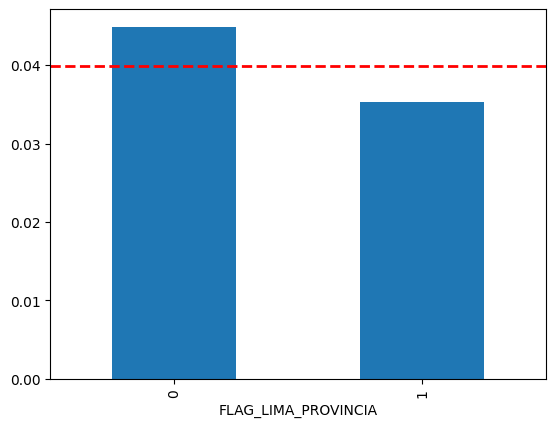

In [47]:
#Grafica de barra de la distribucion entre atributo y TARGET
data_plot=dist_target.TARGET['mean']
threshold=df['TARGET'].value_counts(1)[1]


plt = data_plot.plot(kind='bar')
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=2)

### **Conclusiones del Analisis de Variables**

***Variables importantes para incluir en el modelo***

### Variables Cuantitativas

Variables Cuantitativas - Con base correlaciones altas entre variables, una correlacion (positiva o negativa) mayor al 1.5% con respecto al  target y a la distribucion del histograma*:
- Ahorro_Sldo_Bco_T1
- LINEA_RENOVADO
- PLAZO_RENOVADO
- ENTIDADES_TOTALES
- DIFF_ENTIDADES_TOTALES
- EDAD*
- ANTIGUEDAD_MES
- PRESTAMO_VIGENTE
- PROM_DEUDA_6M
- SUELDO_ESTIMADO
- USO_LINEA_TOTAL_TC_T2
- USO_TRIM_LINEA_BBVA
- SDO_CONSUMO_T2
- MESES_OFERTA_RENOV

En el analisis previo se puede deducir que los valores NULOS de ambas variables **'USO_LINEA_TOTAL_TC_T2'** y **'USO_TRIM_LINEA_BBVA** representan *CLIENTES SIN LINEA*

Por lo que al imputar los nulos se deben de representar con un *VALOR UNICO* (por ejemplo, -1) que represente CLIENTES SIN LINEA.

Se observa que los valores NULOS de SDO_CONSUMO_T2 solo se presentan cuando los valores de USO_LINEA_TOTAL_TC_T2 son CEROS o NULOS, por lo que coincide con la logica de negocio:
- Los clientes que NO contaron con linea de TC (USO_LINEA_TOTAL_TC_T2 = NULO) o No usaron la linea de TC (USO_LINEA_TOTAL_TC_T2=0), no deben tener monto de saldo de consumo (SDO_CONSUMO_T2=0)

Tambien se encontró 5 variables numericas que presentan valores negativos, de los cuales 4 no hacen logica al negocio y se presentan menos del 1% del total de los datos:
- Ahorro_Sldo_Bco_T1
- PRESTAMO_VIGENTE
- PROM_DEUDA_6M

Por lo estas variables deben toparse (Clipping) a 0.

Asi mismo, se observaron grandes diferencies en proporcion del percentil 99.0 contra el percentil 99.9 provocando cola larga y outliers a manejar con upper clip al percentil 99.0 para las variables:
* SDO_CONSUMO_T2
* SUELDO_ESTIMADO
* PROM_DEUDA_6M
* Ahorro_Sldo_Bco_T1
* PRESTAMO_VIGENTE
* DEUDA_CUBIERTA_RENOV

---

### Variables Cualitativas

Variables Cualitativas - Con base a una media de la distribucion entre el atributo con el "TARGET" mayor al promedio del "TARGET":
- SEXO
- EST_CIVIL
- REGION
- FLAG_LIMA_PROVINCIA

Se observo que existen valores "x" e "y" en la columna de "EST_CIVIL" que son irrelevantes y se presentan como "Ruido", ademas de que no aporta valor al TARGET. Por lo que se debe realizar una agrupación por Moda.


### **Tratamiento de Valores Nulos**

**4** Variables de ***20*** con porcentaje de nulos > 5%
* USO_LINEA_TOTAL_TC_T2
* USO_TRIM_LINEA_BBVA
* SDO_CONSUMO_T2
* MESES_OFERTA_RENOV

**3** Variables de ***20*** con porcentaje de nulos < 5%
* SUELDO_ESTIMADO
* ANTIGUEDAD_MES
* EDAD

In [48]:
#Funcion de imputacion de datos
def dataInput(nombre_columna,nombre_target):
  print(f'Funcion de imputacion de datos de la columna \"{nombre_columna}\" con respecto al target \"{nombre_target}\"')

  try:
    total_isna=df[nombre_columna].isna().sum()
    if total_isna == 0:
      print(f'No existen celdas vacias en la columna {nombre_columna}')
    else:
      total_isnotna=df[nombre_columna].count()

      data_avg = df[nombre_columna].mean()
      data_std = df[nombre_columna].std()

      max_decimales = df[nombre_columna].astype(str).str.extract(r'\.(.*)', expand=False).str.len().max()
      max_decimales=int(max_decimales)

      random.seed(123)
      data_list_new_isnotna = np.random.uniform(data_avg - data_std, data_avg +  data_std,size = total_isna).round(max_decimales)

      print(f'Total de celdas NO VACIAS de la columna {nombre_columna}\t=\t{total_isnotna}')
      print(f'Total de celdas VACIAS de la columna {nombre_columna}\t=\t{total_isna}')

      print(f'Total de celdas vacias de {nombre_columna} con respecto al {nombre_target}\n{df.loc[df[nombre_columna].isna()][nombre_target].value_counts()}')

      print(f'PROCESO DE IMPUTACION DE DATOS EN COLUMNA: {nombre_columna}')
      df.loc[np.isnan(df[nombre_columna]), nombre_columna] = data_list_new_isnotna

      print(f'Total de celdas de columna {nombre_columna} despues de la impotacion de datos:\t{df[nombre_columna].count()}')

  except Exception as Err:
    print(f'Error en la funcion causado por:\n{Err}')


In [49]:
#Imputacion de datos para variable: SUELDO_ESTIMADO
dataInput('SUELDO_ESTIMADO','TARGET')

Funcion de imputacion de datos de la columna "SUELDO_ESTIMADO" con respecto al target "TARGET"
Total de celdas NO VACIAS de la columna SUELDO_ESTIMADO	=	87519
Total de celdas VACIAS de la columna SUELDO_ESTIMADO	=	37
Total de celdas vacias de SUELDO_ESTIMADO con respecto al TARGET
TARGET
0    34
1     3
Name: count, dtype: int64
PROCESO DE IMPUTACION DE DATOS EN COLUMNA: SUELDO_ESTIMADO
Total de celdas de columna SUELDO_ESTIMADO despues de la impotacion de datos:	87556


In [50]:
#Imputacion de datos para variable: SUELDO_ESTIMADO
dataInput('ANTIGUEDAD_MES','TARGET')

Funcion de imputacion de datos de la columna "ANTIGUEDAD_MES" con respecto al target "TARGET"
Total de celdas NO VACIAS de la columna ANTIGUEDAD_MES	=	87555
Total de celdas VACIAS de la columna ANTIGUEDAD_MES	=	1
Total de celdas vacias de ANTIGUEDAD_MES con respecto al TARGET
TARGET
0    1
Name: count, dtype: int64
PROCESO DE IMPUTACION DE DATOS EN COLUMNA: ANTIGUEDAD_MES
Total de celdas de columna ANTIGUEDAD_MES despues de la impotacion de datos:	87556


In [51]:
#Imputacion de datos para variable: SUELDO_ESTIMADO
dataInput('EDAD','TARGET')

Funcion de imputacion de datos de la columna "EDAD" con respecto al target "TARGET"
Total de celdas NO VACIAS de la columna EDAD	=	87555
Total de celdas VACIAS de la columna EDAD	=	1
Total de celdas vacias de EDAD con respecto al TARGET
TARGET
0    1
Name: count, dtype: int64
PROCESO DE IMPUTACION DE DATOS EN COLUMNA: EDAD
Total de celdas de columna EDAD despues de la impotacion de datos:	87556


In [52]:
#Imputacion de datos para variable: MESES_OFERTA_RENOV
dataInput('MESES_OFERTA_RENOV','TARGET')
df['MESES_OFERTA_RENOV'] = df['MESES_OFERTA_RENOV'].astype(int)

Funcion de imputacion de datos de la columna "MESES_OFERTA_RENOV" con respecto al target "TARGET"
Total de celdas NO VACIAS de la columna MESES_OFERTA_RENOV	=	73700
Total de celdas VACIAS de la columna MESES_OFERTA_RENOV	=	13856
Total de celdas vacias de MESES_OFERTA_RENOV con respecto al TARGET
TARGET
0    12873
1      983
Name: count, dtype: int64
PROCESO DE IMPUTACION DE DATOS EN COLUMNA: MESES_OFERTA_RENOV
Total de celdas de columna MESES_OFERTA_RENOV despues de la impotacion de datos:	87556


In [53]:
# Igualar a -1 los valores nulos de USO_LINEA_TOTAL_TC_T2 & USO_TRIM_LINEA_BBVA

print(f'Valores nulos en USO_LINEA_TOTAL_TC_T2: {df['USO_LINEA_TOTAL_TC_T2'].isna().sum()}')
df.fillna({'USO_LINEA_TOTAL_TC_T2': -1}, inplace=True)
print(f'Actualizacion de valores nulos en USO_LINEA_TOTAL_TC_T2: {df['USO_LINEA_TOTAL_TC_T2'].isna().sum()}')

print(f'Valores nulos en USO_TRIM_LINEA_BBVA: {df['USO_TRIM_LINEA_BBVA'].isna().sum()}')
df.fillna({'USO_TRIM_LINEA_BBVA': -1}, inplace=True)
print(f'Actualizacion de valores nulos en USO_TRIM_LINEA_BBVA: {df['USO_TRIM_LINEA_BBVA'].isna().sum()}')


Valores nulos en USO_LINEA_TOTAL_TC_T2: 19192
Actualizacion de valores nulos en USO_LINEA_TOTAL_TC_T2: 0
Valores nulos en USO_TRIM_LINEA_BBVA: 19192
Actualizacion de valores nulos en USO_TRIM_LINEA_BBVA: 0


In [54]:
# Igualar a 0 los valores nulos de SDO_CONSUMO_T2 y crear columna FLAG_NULL_SDO_CONSUMO_T2
print(f'Creacion de columna FLAG_NULL_SDO_CONSUMO_T2 donde 1 representa valor Nulo de SDO_CONSUMO_T2\n')
df['FLAG_NULL_SDO_CONSUMO_T2'] = np.where(df['SDO_CONSUMO_T2'].isna(), 1, 0)
print(f'Total de valores de columna FLAG_NULL_SDO_CONSUMO_T2: {df['FLAG_NULL_SDO_CONSUMO_T2'].value_counts(0)}\n')

print(f'Valores nulos en SDO_CONSUMO_T2: {df['SDO_CONSUMO_T2'].isna().sum()}')
print(f'Proceso de reemplazo de nulos en SDO_CONSUMO_T2 por 0')
df.fillna({'SDO_CONSUMO_T2': 0}, inplace=True)
print(f'Valores nulos en SDO_CONSUMO_T2: {df['SDO_CONSUMO_T2'].isna().sum()}')

Creacion de columna FLAG_NULL_SDO_CONSUMO_T2 donde 1 representa valor Nulo de SDO_CONSUMO_T2

Total de valores de columna FLAG_NULL_SDO_CONSUMO_T2: FLAG_NULL_SDO_CONSUMO_T2
0    82370
1     5186
Name: count, dtype: int64

Valores nulos en SDO_CONSUMO_T2: 5186
Proceso de reemplazo de nulos en SDO_CONSUMO_T2 por 0
Valores nulos en SDO_CONSUMO_T2: 0


In [55]:
df['FLAG_NULL_SDO_CONSUMO_T2'].value_counts(0)

,count
FLAG_NULL_SDO_CONSUMO_T2,
0,82370
1,5186


### **Tratamiento de Valores Numericos**

#### Variables Numericas con Valores Negativos
Eliminacion de valores negativos en las variables:
* 'Ahorro_Sldo_Bco_T1'
* 'PRESTAMO_VIGENTE'
* 'PROM_DEUDA_6M'
* 'SUELDO_ESTIMADO'

In [56]:
#Topar a cero las variables con valores negativos.

cols_topar_cero= ['Ahorro_Sldo_Bco_T1', 'PRESTAMO_VIGENTE', 'PROM_DEUDA_6M','SUELDO_ESTIMADO']
print("\n\nPROCESO DE TOPAR VALORES NEGATIVOS A 0")

for col in cols_topar_cero:
    print(f'\nCantidad de valores negativos para {col}: {(df[col] < 0).sum()}')
    print(df[df[col] < 0][col])
    df[col] = df[col].clip(lower=0)
    print(f'\nNUEVA cantidad de valores negativos para {col}: {(df[col] < 0).sum()}')



PROCESO DE TOPAR VALORES NEGATIVOS A 0

Cantidad de valores negativos para Ahorro_Sldo_Bco_T1: 4
2260    -320
33925   -111
37627   -979
86295    -92
Name: Ahorro_Sldo_Bco_T1, dtype: int64

NUEVA cantidad de valores negativos para Ahorro_Sldo_Bco_T1: 0

Cantidad de valores negativos para PRESTAMO_VIGENTE: 1
6771   -98
Name: PRESTAMO_VIGENTE, dtype: int64

NUEVA cantidad de valores negativos para PRESTAMO_VIGENTE: 0

Cantidad de valores negativos para PROM_DEUDA_6M: 2
22932   -1123.8000
29429    -934.8333
Name: PROM_DEUDA_6M, dtype: float64

NUEVA cantidad de valores negativos para PROM_DEUDA_6M: 0

Cantidad de valores negativos para SUELDO_ESTIMADO: 9
19002     -62.6390
22748   -1217.2410
23839    -229.0780
24113    -223.5960
25811    -683.0390
41609    -161.6330
54276    -506.3560
67492    -984.2950
85446    -249.8100
Name: SUELDO_ESTIMADO, dtype: float64

NUEVA cantidad de valores negativos para SUELDO_ESTIMADO: 0


#### Variables Numericas con Valores Outliers hacia arriba
Topar hacia arriba los valores Outliers en las variables:
* SDO_CONSUMO_T2
* SUELDO_ESTIMADO
* PROM_DEUDA_6M
* Ahorro_Sldo_Bco_T1
* PRESTAMO_VIGENTE
* DEUDA_CUBIERTA_RENOV

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
#Funcion para topar hacia arriba
def outlier_capping(x,percentil_objetivo):
    x = x.clip(upper=x.quantile(percentil_objetivo))
    return(x)

Diferencia del percentil 99.0 contra el 99.9:	117790.31
Diferencia proprocial entre percentiles de:	2.13

Datos estadisticas de SDO_CONSUMO_T2 
       SDO_CONSUMO_T2
count      87556.0000
mean       13533.1290
std        21195.2852
min            0.0000
25%         3360.0400
50%         7821.5700
75%        15155.6950
max       722781.0900

Nuevos datos estadisticas de SDO_CONSUMO_T2 
       SDO_CONSUMO_T2
count      87556.0000
mean       13011.8650
std        17118.6555
min            0.0000
25%         3360.0400
50%         7821.5700
75%        15155.6950
max       103915.5395



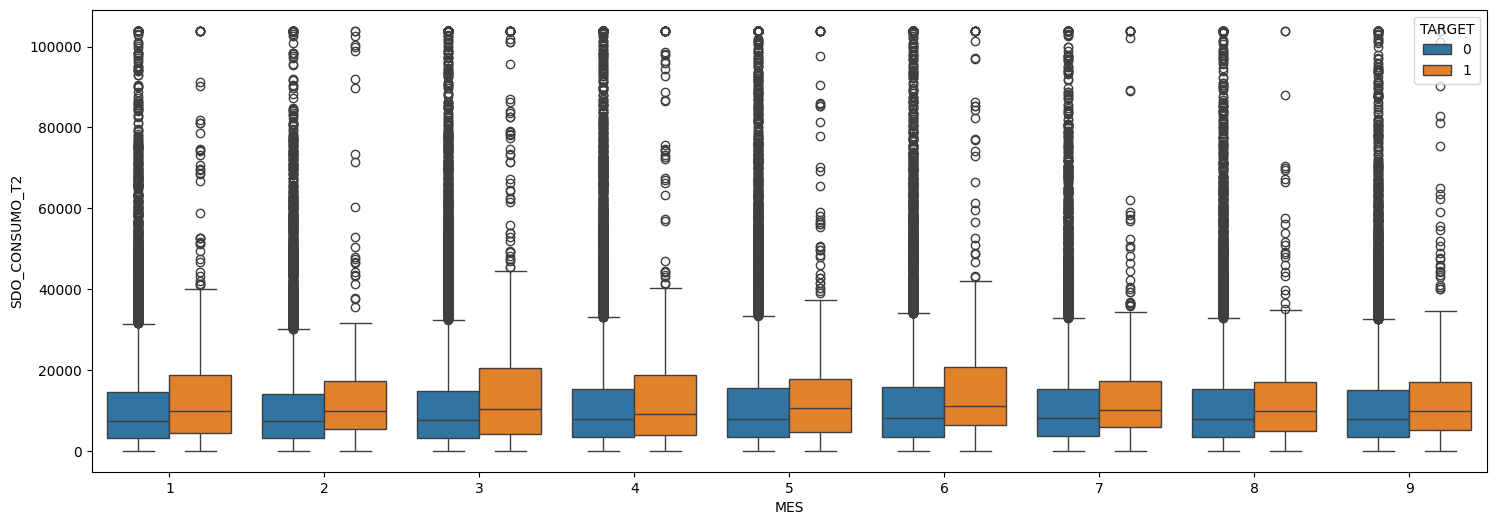

In [59]:
#Topar al percenti 0.99 la variable SDO_CONSUMO_T2

print(f'Diferencia del percentil 99.0 contra el 99.9:\t{(df['SDO_CONSUMO_T2'].quantile(0.999))-(df['SDO_CONSUMO_T2'].quantile(0.99)):.2f}')
print(f'Diferencia proprocial entre percentiles de:\t{(df['SDO_CONSUMO_T2'].quantile(0.999))/(df['SDO_CONSUMO_T2'].quantile(0.99)):.2f}')

print(f'\nDatos estadisticas de SDO_CONSUMO_T2 \n{df[['SDO_CONSUMO_T2']].describe()}')
df['SDO_CONSUMO_T2']= df[['SDO_CONSUMO_T2']].apply(lambda x: outlier_capping(x,0.99))
print(f'\nNuevos datos estadisticas de SDO_CONSUMO_T2 \n{df[['SDO_CONSUMO_T2']].describe()}\n')

plt.figure(figsize=(18,6))
sns.boxplot(x="MES", y="SDO_CONSUMO_T2", hue="TARGET", data=df)
plt.show()

Diferencia del percentil 99.0 contra el 99.9:	38523.00
Diferencia proprocial entre percentiles de:	2.56

Datos estadisticas de SUELDO_ESTIMADO 
       SUELDO_ESTIMADO
count       87556.0000
mean         4765.8792
std          6003.0803
min             0.0000
25%          2183.4900
50%          3178.1200
75%          5599.0000
max        240909.0000

Nuevos datos estadisticas de SUELDO_ESTIMADO 
       SUELDO_ESTIMADO
count       87556.0000
mean         4591.9740
std          4145.3595
min             0.0000
25%          2183.4900
50%          3178.1200
75%          5599.0000
max         24750.0000



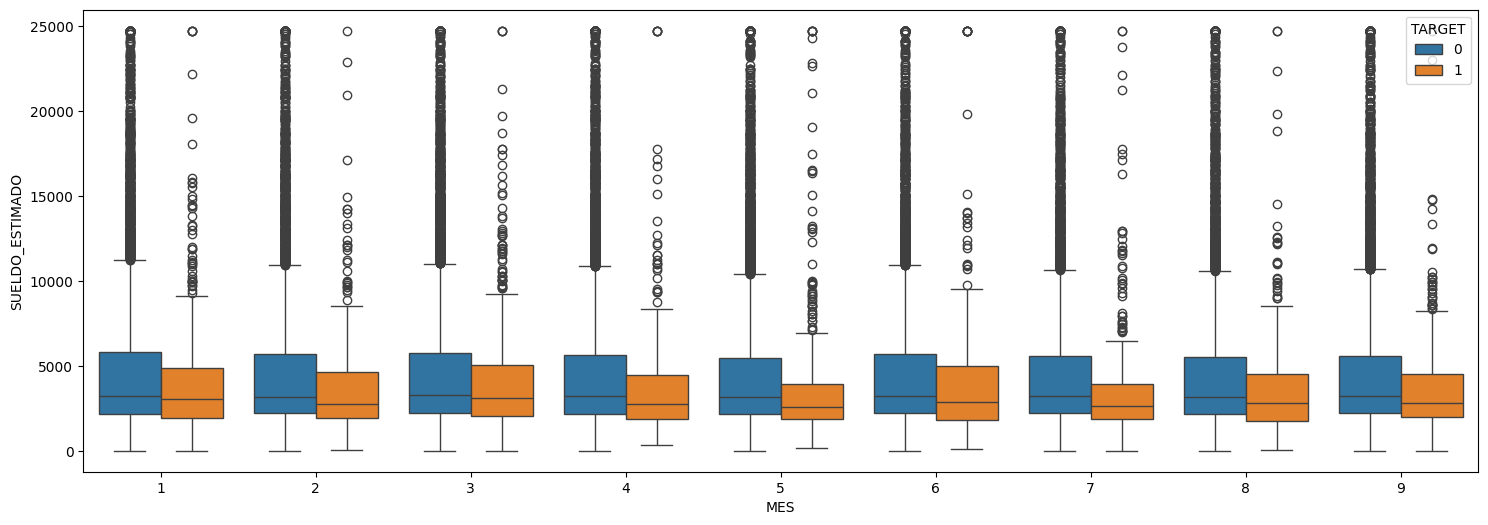

In [60]:
#Topar al percenti 0.99 la variable SUELDO_ESTIMADO

print(f'Diferencia del percentil 99.0 contra el 99.9:\t{(df['SUELDO_ESTIMADO'].quantile(0.999))-(df['SUELDO_ESTIMADO'].quantile(0.99)):.2f}')
print(f'Diferencia proprocial entre percentiles de:\t{(df['SUELDO_ESTIMADO'].quantile(0.999))/(df['SUELDO_ESTIMADO'].quantile(0.99)):.2f}')

print(f'\nDatos estadisticas de SUELDO_ESTIMADO \n{df[['SUELDO_ESTIMADO']].describe()}')
df['SUELDO_ESTIMADO']= df[['SUELDO_ESTIMADO']].apply(lambda x: outlier_capping(x,0.99))
print(f'\nNuevos datos estadisticas de SUELDO_ESTIMADO \n{df[['SUELDO_ESTIMADO']].describe()}\n')

plt.figure(figsize=(18,6))
sns.boxplot(x="MES", y="SUELDO_ESTIMADO", hue="TARGET", data=df)
plt.show()

Diferencia del percentil 99.0 contra el 99.9:	952869.72
Diferencia proprocial entre percentiles de:	3.87

Datos estadisticas de PROM_DEUDA_6M 
       PROM_DEUDA_6M
count     87556.0000
mean      28746.1046
std      122550.0890
min           0.0000
25%        1002.7917
50%        6363.1667
75%       23710.3333
max     9077797.0000

Nuevos datos estadisticas de PROM_DEUDA_6M 
       PROM_DEUDA_6M
count     87556.0000
mean      24312.8371
std       50229.8764
min           0.0000
25%        1002.7917
50%        6363.1667
75%       23710.3333
max      331911.6833



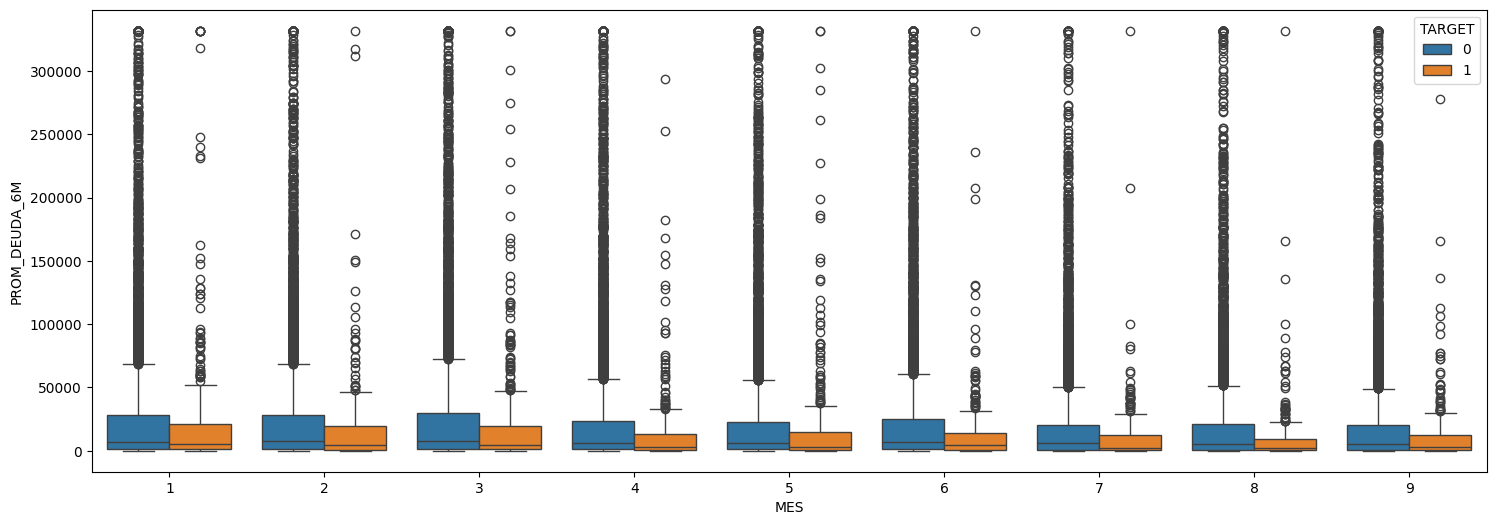

In [61]:
#Topar al percenti 0.99 la variable PROM_DEUDA_6M

print(f'Diferencia del percentil 99.0 contra el 99.9:\t{(df['PROM_DEUDA_6M'].quantile(0.999))-(df['PROM_DEUDA_6M'].quantile(0.99)):.2f}')
print(f'Diferencia proprocial entre percentiles de:\t{(df['PROM_DEUDA_6M'].quantile(0.999))/(df['PROM_DEUDA_6M'].quantile(0.99)):.2f}')

print(f'\nDatos estadisticas de PROM_DEUDA_6M \n{df[['PROM_DEUDA_6M']].describe()}')
df['PROM_DEUDA_6M']= df[['PROM_DEUDA_6M']].apply(lambda x: outlier_capping(x,0.99))
print(f'\nNuevos datos estadisticas de PROM_DEUDA_6M \n{df[['PROM_DEUDA_6M']].describe()}\n')

plt.figure(figsize=(18,6))
sns.boxplot(x="MES", y="PROM_DEUDA_6M", hue="TARGET", data=df)
plt.show()

Diferencia del percentil 99.0 contra el 99.9:	520323.08
Diferencia proprocial entre percentiles de:	4.33

Datos estadisticas de Ahorro_Sldo_Bco_T1 
       Ahorro_Sldo_Bco_T1
count          87556.0000
mean           10805.5652
std            70683.6180
min                0.0000
25%              147.0000
50%             1208.0000
75%             5246.0000
max          8597760.0000

Nuevos datos estadisticas de Ahorro_Sldo_Bco_T1 
       Ahorro_Sldo_Bco_T1
count          87556.0000
mean            8325.8064
std            22291.8082
min                0.0000
25%              147.0000
50%             1208.0000
75%             5246.0000
max           156260.0000



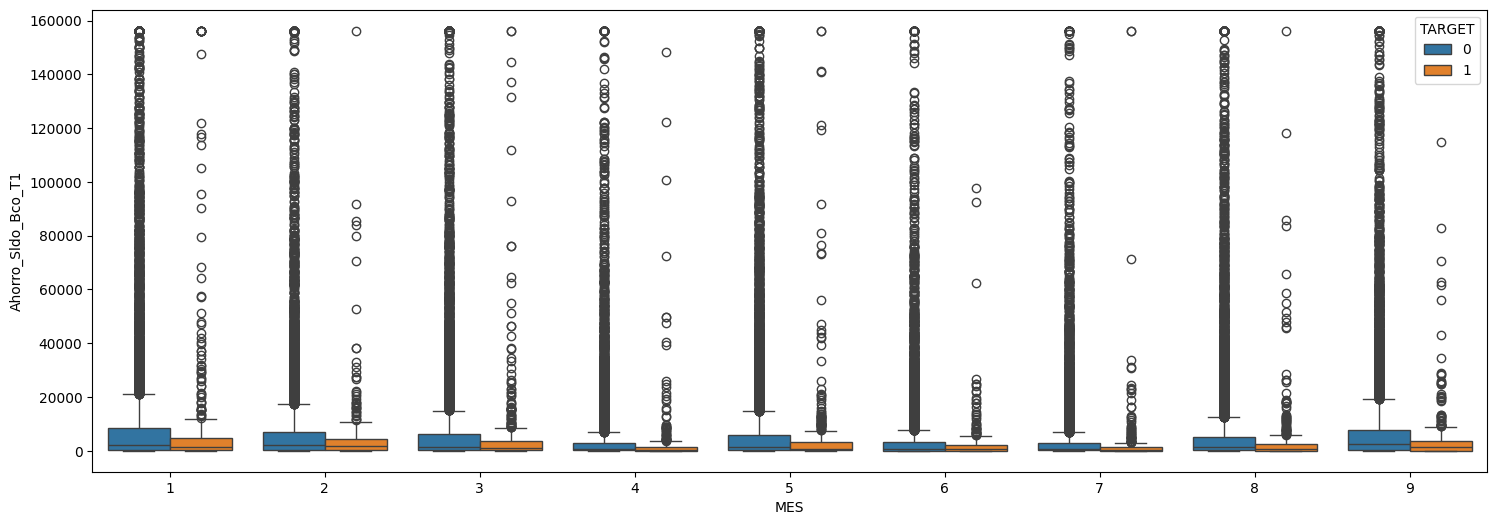

In [62]:
#Topar al percenti 0.99 la variable Ahorro_Sldo_Bco_T1

print(f'Diferencia del percentil 99.0 contra el 99.9:\t{(df['Ahorro_Sldo_Bco_T1'].quantile(0.999))-(df['Ahorro_Sldo_Bco_T1'].quantile(0.99)):.2f}')
print(f'Diferencia proprocial entre percentiles de:\t{(df['Ahorro_Sldo_Bco_T1'].quantile(0.999))/(df['Ahorro_Sldo_Bco_T1'].quantile(0.99)):.2f}')

print(f'\nDatos estadisticas de Ahorro_Sldo_Bco_T1 \n{df[['Ahorro_Sldo_Bco_T1']].describe()}')
df['Ahorro_Sldo_Bco_T1']= df[['Ahorro_Sldo_Bco_T1']].apply(lambda x: outlier_capping(x,0.99))
print(f'\nNuevos datos estadisticas de Ahorro_Sldo_Bco_T1 \n{df[['Ahorro_Sldo_Bco_T1']].describe()}\n')

plt.figure(figsize=(18,6))
sns.boxplot(x="MES", y="Ahorro_Sldo_Bco_T1", hue="TARGET", data=df)
plt.show()

Diferencia del percentil 99.0 contra el 99.9:	223561.65
Diferencia proprocial entre percentiles de:	2.43

Datos estadisticas de PRESTAMO_VIGENTE 
       PRESTAMO_VIGENTE
count        87556.0000
mean         19673.2943
std          35031.9474
min              0.0000
25%           3954.0000
50%          10162.0000
75%          21453.0000
max        2132740.0000

Nuevos datos estadisticas de PRESTAMO_VIGENTE 
       PRESTAMO_VIGENTE
count        87556.0000
mean         18738.9100
std          26245.4318
min              0.0000
25%           3954.0000
50%          10162.0000
75%          21453.0000
max         156130.8000



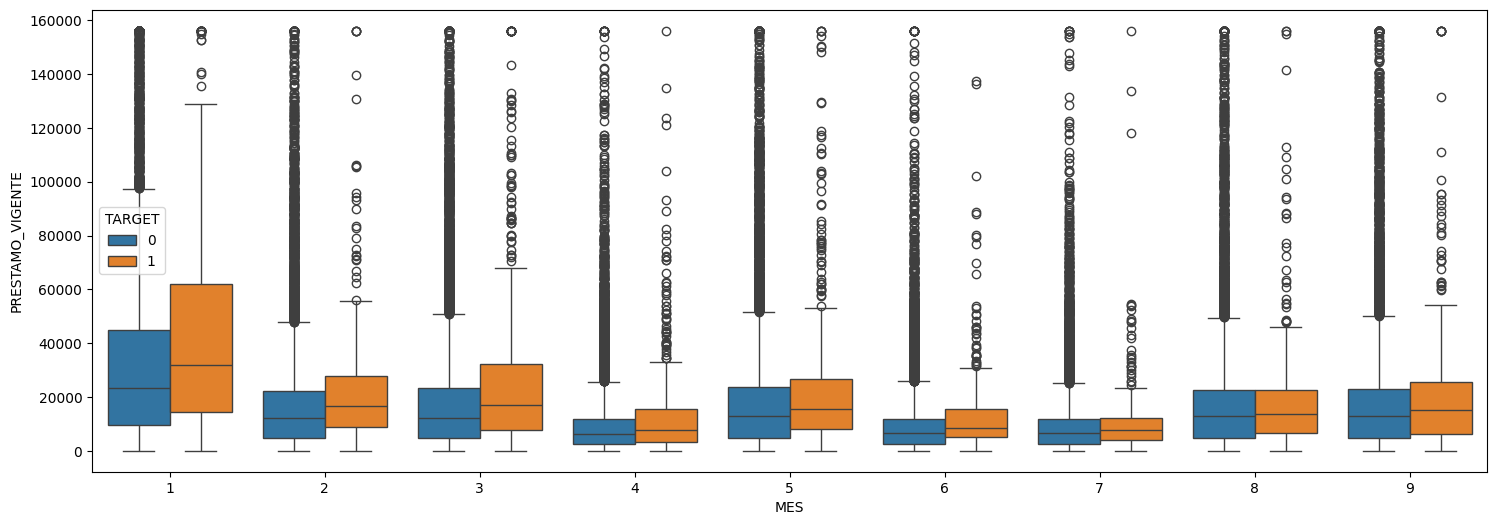

In [63]:
#Topar al percenti 0.99 la variable PRESTAMO_VIGENTE

print(f'Diferencia del percentil 99.0 contra el 99.9:\t{(df['PRESTAMO_VIGENTE'].quantile(0.999))-(df['PRESTAMO_VIGENTE'].quantile(0.99)):.2f}')
print(f'Diferencia proprocial entre percentiles de:\t{(df['PRESTAMO_VIGENTE'].quantile(0.999))/(df['PRESTAMO_VIGENTE'].quantile(0.99)):.2f}')

print(f'\nDatos estadisticas de PRESTAMO_VIGENTE \n{df[['PRESTAMO_VIGENTE']].describe()}')
df['PRESTAMO_VIGENTE']= df[['PRESTAMO_VIGENTE']].apply(lambda x: outlier_capping(x,0.99))
print(f'\nNuevos datos estadisticas de PRESTAMO_VIGENTE \n{df[['PRESTAMO_VIGENTE']].describe()}\n')

plt.figure(figsize=(18,6))
sns.boxplot(x="MES", y="PRESTAMO_VIGENTE", hue="TARGET", data=df)
plt.show()

Diferencia del percentil 99.0 contra el 99.9:	7.58
Diferencia proprocial entre percentiles de:	2.58

Datos estadisticas de DEUDA_CUBIERTA_RENOV 
       DEUDA_CUBIERTA_RENOV
count            87556.0000
mean                 0.7378
std                  1.0388
min                  0.0000
25%                  0.3265
50%                  0.5481
75%                  0.7751
max                 52.4342

Nuevos datos estadisticas de DEUDA_CUBIERTA_RENOV 
       DEUDA_CUBIERTA_RENOV
count            87556.0000
mean                 0.7058
std                  0.7484
min                  0.0000
25%                  0.3265
50%                  0.5481
75%                  0.7751
max                  4.7862



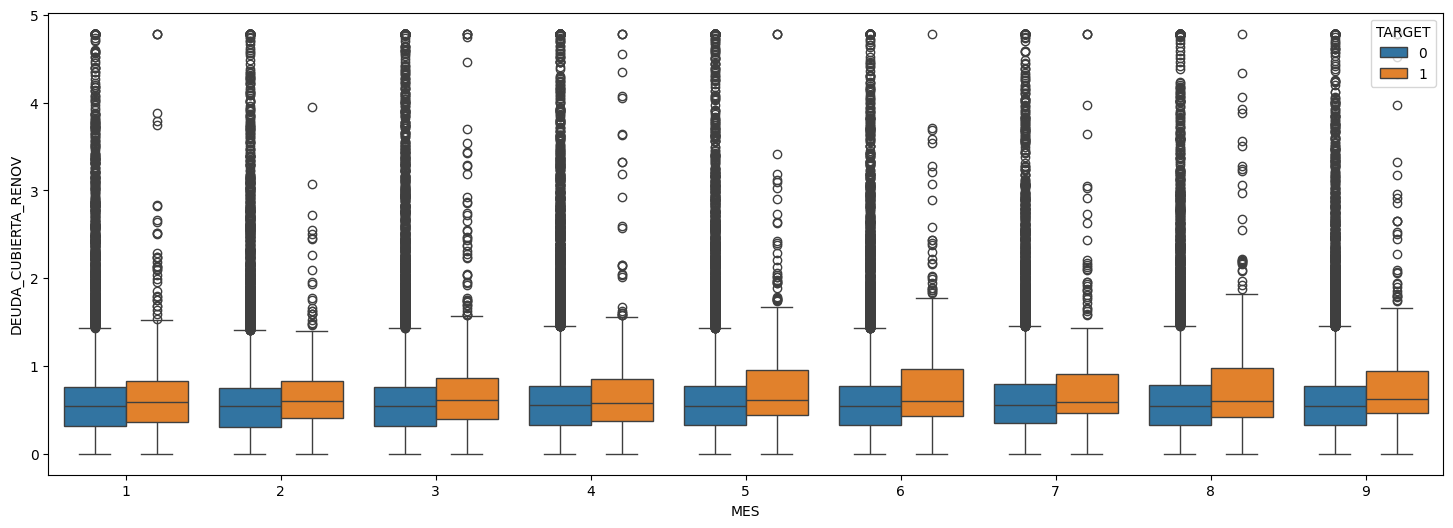

In [64]:
#Topar al percenti 0.99 la variable DEUDA_CUBIERTA_RENOV

print(f'Diferencia del percentil 99.0 contra el 99.9:\t{(df['DEUDA_CUBIERTA_RENOV'].quantile(0.999))-(df['DEUDA_CUBIERTA_RENOV'].quantile(0.99)):.2f}')
print(f'Diferencia proprocial entre percentiles de:\t{(df['DEUDA_CUBIERTA_RENOV'].quantile(0.999))/(df['DEUDA_CUBIERTA_RENOV'].quantile(0.99)):.2f}')

print(f'\nDatos estadisticas de DEUDA_CUBIERTA_RENOV \n{df[['DEUDA_CUBIERTA_RENOV']].describe()}')
df['DEUDA_CUBIERTA_RENOV']= df[['DEUDA_CUBIERTA_RENOV']].apply(lambda x: outlier_capping(x,0.99))
print(f'\nNuevos datos estadisticas de DEUDA_CUBIERTA_RENOV \n{df[['DEUDA_CUBIERTA_RENOV']].describe()}\n')

plt.figure(figsize=(18,6))
sns.boxplot(x="MES", y="DEUDA_CUBIERTA_RENOV", hue="TARGET", data=df)
plt.show()

### **Tratamiento de Valores No Numericos**
* Sustituir variables ruidosas (x e y) de EST_CIVIL por la moda.
* Limpiar de valores na de las variables sustiyuyendo por la moda.
* Encoding de variables cualitativas a numericas para implementar modelo:
   - SEXO
   - EST_CIVIL
   - REGION

In [65]:
#Sustitucion del valor X y Y por Valor Moda de EST_CIVIL.
valor_moda=df['EST_CIVIL'].mode()[0]
print(f'Cantidad de registros de EST_CIVIL ANTES de sustitucion:\n{df['EST_CIVIL'].value_counts(1)}\n')
print(f'Cantidad de distribucion de EST_CIVIL con TARGET ANTES de sustitucion:\n{df[['EST_CIVIL','TARGET']].groupby(by='EST_CIVIL').agg(['count','sum','mean'])}\n')
print(f'Valor Moda de EST_CIVL:\t{valor_moda}')

print(f'\nReemplazamiento de valores X e Y por la moda {valor_moda}')
df['EST_CIVIL'] = df['EST_CIVIL'].replace({'X': valor_moda, 'Y': valor_moda})
df['EST_CIVIL'] = df['EST_CIVIL'].fillna(valor_moda)

print(f'\nCantidad de registros de EST_CIVIL DESPUES de sustitucion:\n{df['EST_CIVIL'].value_counts(1)}\n')
print(f'Cantidad de distribucion de EST_CIVIL con TARGET ANTES de sustitucion:\n{df[['EST_CIVIL','TARGET']].groupby(by='EST_CIVIL').agg(['count','sum','mean'])}\n')

print(f'\nCantidad de registros de EST_CIVIL DESPUES de sustitucion:\n{df['EST_CIVIL'].count()}\n')

Cantidad de registros de EST_CIVIL ANTES de sustitucion:
EST_CIVIL
S   0.5064
C   0.4298
U   0.0314
D   0.0233
V   0.0090
Y   0.0001
X   0.0000
Name: proportion, dtype: float64

Cantidad de distribucion de EST_CIVIL con TARGET ANTES de sustitucion:
          TARGET             
           count   sum   mean
EST_CIVIL                    
C          37631  1449 0.0385
D           2037    86 0.0422
S          44341  1811 0.0408
U           2749   120 0.0437
V            788    26 0.0330
X              1     0 0.0000
Y              8     0 0.0000

Valor Moda de EST_CIVL:	S

Reemplazamiento de valores X e Y por la moda S

Cantidad de registros de EST_CIVIL DESPUES de sustitucion:
EST_CIVIL
S   0.5065
C   0.4298
U   0.0314
D   0.0233
V   0.0090
Name: proportion, dtype: float64

Cantidad de distribucion de EST_CIVIL con TARGET ANTES de sustitucion:
          TARGET             
           count   sum   mean
EST_CIVIL                    
C          37631  1449 0.0385
D           2037    86 0.0

In [66]:
#Sustitucion del valores NAN por Valor Moda de SEXO.
print(f'Valores unicos de la columna SEXO:\t{df['SEXO'].unique()}')
print(f'Cantidad de registros de SEXO ANTES de sustitucion:\n{df['SEXO'].value_counts(1)}\n')
print(f'Cantidad de distribucion de SEXO con TARGET ANTES de sustitucion:\n{df[['SEXO','TARGET']].groupby(by='SEXO').agg(['count','sum','mean'])}\n')

valor_moda=df['SEXO'].mode()[0]

print(f'\nReemplazamiento de valor NAN  por la moda: {valor_moda}')
df['SEXO'] = df['SEXO'].fillna(valor_moda)

print(f'\nCantidad de registros de SEXO DESPUES de sustitucion:\n{df['SEXO'].value_counts(1)}\n')
print(f'Cantidad de distribucion de SEXO con TARGET DESPUES de sustitucion:\n{df[['SEXO','TARGET']].groupby(by='SEXO').agg(['count','sum','mean'])}\n')

print(f'\nCantidad de registros de SEXO DESPUES de sustitucion:\n{df['SEXO'].count()}\n')
print(f'Valores unicos de la columna SEXO:\t{df['SEXO'].unique()}')

Valores unicos de la columna SEXO:	['M' 'F' nan]
Cantidad de registros de SEXO ANTES de sustitucion:
SEXO
M   0.7014
F   0.2986
Name: proportion, dtype: float64

Cantidad de distribucion de SEXO con TARGET ANTES de sustitucion:
     TARGET             
      count   sum   mean
SEXO                    
F     26141   936 0.0358
M     61414  2556 0.0416


Reemplazamiento de valor NAN  por la moda: M

Cantidad de registros de SEXO DESPUES de sustitucion:
SEXO
M   0.7014
F   0.2986
Name: proportion, dtype: float64

Cantidad de distribucion de SEXO con TARGET DESPUES de sustitucion:
     TARGET             
      count   sum   mean
SEXO                    
F     26141   936 0.0358
M     61415  2556 0.0416


Cantidad de registros de SEXO DESPUES de sustitucion:
87556

Valores unicos de la columna SEXO:	['M' 'F']


In [67]:
#Sustitucion del valores NAN por Valor Moda de REGION.
print(f'Valores unicos de la columna REGION:\t{df['REGION'].unique()}')
print(f'Cantidad de registros de REGION ANTES de sustitucion:\n{df['REGION'].value_counts(1)}\n')
print(f'Cantidad de distribucion de REGION con TARGET ANTES de sustitucion:\n{df[['REGION','TARGET']].groupby(by='REGION').agg(['count','sum','mean'])}\n')

valor_moda=df['REGION'].mode()[0]

print(f'\nReemplazamiento de valor NAN  por la moda: {valor_moda}')
df['REGION'] = df['REGION'].fillna(valor_moda)

print(f'\nCantidad de registros de REGION DESPUES de sustitucion:\n{df['REGION'].value_counts(1)}\n')
print(f'Cantidad de distribucion de REGION con TARGET DESPUES de sustitucion:\n{df[['REGION','TARGET']].groupby(by='REGION').agg(['count','sum','mean'])}\n')

print(f'\nCantidad de registros de REGION DESPUES de sustitucion:\n{df['REGION'].count()}\n')
print(f'Valores unicos de la columna REGION:\t{df['REGION'].unique()}')

Valores unicos de la columna REGION:	['LIMA NORTE' 'LIMA ESTE' 'LIMA MODERNA' 'NORTE' 'LIMA SUR' 'CENTRO' 'SUR'
 'LIMA CENTRO' 'SIERRA CENTRAL' 'OESTE' 'CALLAO' 'LIMA PROVINCIA'
 'ORIENTE' 'LIMA BALNEARIO' nan]
Cantidad de registros de REGION ANTES de sustitucion:
REGION
LIMA MODERNA     0.1581
CENTRO           0.1141
NORTE            0.1061
LIMA NORTE       0.1025
SUR              0.0954
LIMA ESTE        0.0944
LIMA SUR         0.0717
LIMA CENTRO      0.0622
ORIENTE          0.0484
CALLAO           0.0439
SIERRA CENTRAL   0.0350
LIMA PROVINCIA   0.0346
OESTE            0.0318
LIMA BALNEARIO   0.0017
Name: proportion, dtype: float64

Cantidad de distribucion de REGION con TARGET ANTES de sustitucion:
               TARGET            
                count  sum   mean
REGION                           
CALLAO           3847  133 0.0346
CENTRO           9990  487 0.0487
LIMA BALNEARIO    150    7 0.0467
LIMA CENTRO      5443  203 0.0373
LIMA ESTE        8267  324 0.0392
LIMA MODERNA    13

In [68]:
#Funcion LabelEncoder
def label_encoder(column_name):
  #Transformar Variables (Encoding) Cualitativas con LabelEncoder
  print(f'Transformacion de variables cualitativas con LabelEncoder para la Columna:\t{column_name}')
  print(f'Cantidad de datos sin Encoding:\n{df[column_name].value_counts(0)}')
  print(f'\nVariables Ordenadas Sin Encoding:\n{sorted(df[column_name].unique().tolist())}')
  le = LabelEncoder()
  y_encoded = le.fit_transform(df[column_name])
  df[column_name]=y_encoded
  print(f'\nVariables Ordenadas Con Encoding:\n{sorted(df[column_name].unique().tolist())}')
  print(f'\nCantidad de datos Con Encoding:\n{df[column_name].value_counts(0)}')


In [69]:
label_encoder('EST_CIVIL')

Transformacion de variables cualitativas con LabelEncoder para la Columna:	EST_CIVIL
Cantidad de datos sin Encoding:
EST_CIVIL
S    44351
C    37631
U     2749
D     2037
V      788
Name: count, dtype: int64

Variables Ordenadas Sin Encoding:
['C', 'D', 'S', 'U', 'V']

Variables Ordenadas Con Encoding:
[0, 1, 2, 3, 4]

Cantidad de datos Con Encoding:
EST_CIVIL
2    44351
0    37631
3     2749
1     2037
4      788
Name: count, dtype: int64


In [70]:
df['EST_CIVIL'].describe()

,EST_CIVIL
count,87556.0000
mean,1.1665
std,1.0560
min,0.0000
25%,0.0000
50%,2.0000
75%,2.0000
max,4.0000


In [71]:
label_encoder('SEXO')

Transformacion de variables cualitativas con LabelEncoder para la Columna:	SEXO
Cantidad de datos sin Encoding:
SEXO
M    61415
F    26141
Name: count, dtype: int64

Variables Ordenadas Sin Encoding:
['F', 'M']

Variables Ordenadas Con Encoding:
[0, 1]

Cantidad de datos Con Encoding:
SEXO
1    61415
0    26141
Name: count, dtype: int64


In [72]:
label_encoder('REGION')

Transformacion de variables cualitativas con LabelEncoder para la Columna:	REGION
Cantidad de datos sin Encoding:
REGION
LIMA MODERNA      13854
CENTRO             9990
NORTE              9291
LIMA NORTE         8973
SUR                8348
LIMA ESTE          8267
LIMA SUR           6274
LIMA CENTRO        5443
ORIENTE            4240
CALLAO             3847
SIERRA CENTRAL     3062
LIMA PROVINCIA     3029
OESTE              2788
LIMA BALNEARIO      150
Name: count, dtype: int64

Variables Ordenadas Sin Encoding:
['CALLAO', 'CENTRO', 'LIMA BALNEARIO', 'LIMA CENTRO', 'LIMA ESTE', 'LIMA MODERNA', 'LIMA NORTE', 'LIMA PROVINCIA', 'LIMA SUR', 'NORTE', 'OESTE', 'ORIENTE', 'SIERRA CENTRAL', 'SUR']

Variables Ordenadas Con Encoding:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

Cantidad de datos Con Encoding:
REGION
5     13854
1      9990
9      9291
6      8973
13     8348
4      8267
8      6274
3      5443
11     4240
0      3847
12     3062
7      3029
10     2788
2       150
Name: count

In [73]:
df['REGION'].describe()

,REGION
count,87556.0000
mean,6.3685
std,3.7880
min,0.0000
25%,4.0000
50%,6.0000
75%,9.0000
max,13.0000


In [74]:
# Save the file to a specific folder in your Google Drive
#df.to_csv('/content/drive/MyDrive/ColabNotebooks/smartdata_ciencia_de_datos/csv/renovacion_prestamo_datos_tratados.csv', index=False)

---
## **PARTE II - PARTICION MUESTRAL & BALANCEO DE DATOS**
---

### **Particion muestral del dataset**

In [75]:
#Respaldo de dataframe encoded para referencias
df_encoded=df.copy()
df_encoded.head(5)

,MES,LINEA_RENOVADO,PLAZO_RENOVADO,TARGET,USO_LINEA_TOTAL_TC_T2,USO_TRIM_LINEA_BBVA,ENTIDADES_TOTALES,DIFF_ENTIDADES_TOTALES,SDO_CONSUMO_T2,MESES_OFERTA_RENOV,...,PROM_DEUDA_6M,EDAD,SEXO,EST_CIVIL,ANTIGUEDAD_MES,REGION,FLAG_LIMA_PROVINCIA,SUELDO_ESTIMADO,DEUDA_CUBIERTA_RENOV,FLAG_NULL_SDO_CONSUMO_T2
0,6,3770,12,0,0.0000,0.0000,1,-1,271.1200,21,...,3754.3333,25.0000,1,2,23.0000,6,1,3531.0000,0.0719,0
1,6,1300,6,0,0.0000,0.0000,1,0,11200.0000,9,...,1581.3333,33.0000,1,2,56.0000,4,1,1322.0000,4.7862,0
2,6,7800,36,0,0.4295,0.2256,5,-2,20156.4500,17,...,10241.0000,26.0000,1,2,20.0000,5,1,4234.0000,2.5842,0
3,6,6630,12,0,0.0000,0.0000,1,1,20485.1400,20,...,5797.3333,51.0000,1,2,166.0000,9,0,6647.0000,3.0898,0
4,6,15497,36,1,-1.0000,-1.0000,1,0,1682.8300,11,...,16755.3333,35.0000,1,0,55.0000,9,0,2094.0000,0.1086,0


In [76]:
#Separacion de columna target
X = df.drop('TARGET',axis=1)
y = df['TARGET']

In [77]:
X.head(3)

,MES,LINEA_RENOVADO,PLAZO_RENOVADO,USO_LINEA_TOTAL_TC_T2,USO_TRIM_LINEA_BBVA,ENTIDADES_TOTALES,DIFF_ENTIDADES_TOTALES,SDO_CONSUMO_T2,MESES_OFERTA_RENOV,Ahorro_Sldo_Bco_T1,...,PROM_DEUDA_6M,EDAD,SEXO,EST_CIVIL,ANTIGUEDAD_MES,REGION,FLAG_LIMA_PROVINCIA,SUELDO_ESTIMADO,DEUDA_CUBIERTA_RENOV,FLAG_NULL_SDO_CONSUMO_T2
0,6,3770,12,0.0000,0.0000,1,-1,271.1200,21,1850,...,3754.3333,25.0000,1,2,23.0000,6,1,3531.0000,0.0719,0
1,6,1300,6,0.0000,0.0000,1,0,11200.0000,9,2093,...,1581.3333,33.0000,1,2,56.0000,4,1,1322.0000,4.7862,0
2,6,7800,36,0.4295,0.2256,5,-2,20156.4500,17,16208,...,10241.0000,26.0000,1,2,20.0000,5,1,4234.0000,2.5842,0


In [78]:
y.head(3)

,TARGET
0,0
1,0
2,0


In [79]:
# Calcular dataset de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [80]:
#Resultado de particion de datos de entrenamiento y prueba:
print(f'Tamaño de dataset X Train:\t{len(X_train)}')
print(f'Tamaño de dataset X Test:\t{len(X_test)}')
print(f'Total Dataset X:\t{len(X_train)+len(X_test)}')
print(f'\nTamaño de dataset y Train:\t{len(y_train)}')
print(f'Tamaño de dataset y Test:\t{len(y_test)}')
print(f'Total Dataset y:\t{len(y_train)+len(y_test)}')

Tamaño de dataset X Train:	70044
Tamaño de dataset X Test:	17512
Total Dataset X:	87556

Tamaño de dataset y Train:	70044
Tamaño de dataset y Test:	17512
Total Dataset y:	87556


In [81]:
# Union de datos de de entrenamiento X_train y y_train
df_train = pd.concat([X_train,y_train],axis=1)
df_train.head()

,MES,LINEA_RENOVADO,PLAZO_RENOVADO,USO_LINEA_TOTAL_TC_T2,USO_TRIM_LINEA_BBVA,ENTIDADES_TOTALES,DIFF_ENTIDADES_TOTALES,SDO_CONSUMO_T2,MESES_OFERTA_RENOV,Ahorro_Sldo_Bco_T1,...,EDAD,SEXO,EST_CIVIL,ANTIGUEDAD_MES,REGION,FLAG_LIMA_PROVINCIA,SUELDO_ESTIMADO,DEUDA_CUBIERTA_RENOV,FLAG_NULL_SDO_CONSUMO_T2,TARGET
9512,8,53468,36,0.1960,0.1941,2,0,25265.0800,6,110002,...,36.0000,1,2,144.0000,5,1,7591.0500,0.4725,0,0
29987,8,2273,12,-1.0000,-1.0000,1,-1,1234.1900,11,88,...,49.0000,1,2,53.0000,11,0,894.0000,0.5430,0,0
16355,7,52683,36,0.2224,0.0073,5,-1,94993.6200,6,4043,...,37.0000,1,2,101.0000,4,1,9480.0000,1.8031,0,0
58432,3,6630,24,0.3475,0.2717,1,0,1466.5900,12,872,...,53.0000,1,0,146.0000,9,0,1200.0000,0.2212,0,0
49149,4,13000,36,0.3219,0.6419,2,0,7689.5100,17,0,...,38.0000,0,0,190.0000,3,1,2685.4700,0.5915,0,0


In [82]:
#Variables del total de target por 0 y 1
count_class_0, count_class_1 = df_train['TARGET'].value_counts()
print(f'Total Target del Dataset Train con Valor 0:\t{count_class_0}')
print(f'Total Target del Dataset Train con Valor 1:\t{count_class_1}')
print(f'Total Target del Dataset Train:\t{count_class_0+count_class_1}')

Total Target del Dataset Train con Valor 0:	67248
Total Target del Dataset Train con Valor 1:	2796
Total Target del Dataset Train:	70044


In [83]:
# Divicion de conjunto de datos de entrenamiento
df_train_class_0 = df_train[df_train['TARGET']==0]
df_train_class_1 = df_train[df_train['TARGET']==1]

In [84]:
df_train_class_0.head()

,MES,LINEA_RENOVADO,PLAZO_RENOVADO,USO_LINEA_TOTAL_TC_T2,USO_TRIM_LINEA_BBVA,ENTIDADES_TOTALES,DIFF_ENTIDADES_TOTALES,SDO_CONSUMO_T2,MESES_OFERTA_RENOV,Ahorro_Sldo_Bco_T1,...,EDAD,SEXO,EST_CIVIL,ANTIGUEDAD_MES,REGION,FLAG_LIMA_PROVINCIA,SUELDO_ESTIMADO,DEUDA_CUBIERTA_RENOV,FLAG_NULL_SDO_CONSUMO_T2,TARGET
9512,8,53468,36,0.1960,0.1941,2,0,25265.0800,6,110002,...,36.0000,1,2,144.0000,5,1,7591.0500,0.4725,0,0
29987,8,2273,12,-1.0000,-1.0000,1,-1,1234.1900,11,88,...,49.0000,1,2,53.0000,11,0,894.0000,0.5430,0,0
16355,7,52683,36,0.2224,0.0073,5,-1,94993.6200,6,4043,...,37.0000,1,2,101.0000,4,1,9480.0000,1.8031,0,0
58432,3,6630,24,0.3475,0.2717,1,0,1466.5900,12,872,...,53.0000,1,0,146.0000,9,0,1200.0000,0.2212,0,0
49149,4,13000,36,0.3219,0.6419,2,0,7689.5100,17,0,...,38.0000,0,0,190.0000,3,1,2685.4700,0.5915,0,0


In [85]:
df_train_class_1.head()

,MES,LINEA_RENOVADO,PLAZO_RENOVADO,USO_LINEA_TOTAL_TC_T2,USO_TRIM_LINEA_BBVA,ENTIDADES_TOTALES,DIFF_ENTIDADES_TOTALES,SDO_CONSUMO_T2,MESES_OFERTA_RENOV,Ahorro_Sldo_Bco_T1,...,EDAD,SEXO,EST_CIVIL,ANTIGUEDAD_MES,REGION,FLAG_LIMA_PROVINCIA,SUELDO_ESTIMADO,DEUDA_CUBIERTA_RENOV,FLAG_NULL_SDO_CONSUMO_T2,TARGET
83222,3,26000,24,-1.0000,-1.0000,1,0,6746.3300,15,6410,...,43.0000,1,3,80.0000,4,1,1328.9400,0.2595,0,1
80211,1,16000,35,0.4301,0.0000,4,-1,12783.5400,11,20856,...,38.0000,0,0,128.0000,10,0,5000.0000,0.7990,0,1
58545,3,13000,36,0.1800,0.0000,2,0,3827.9900,3,8336,...,41.0000,1,0,217.0000,9,0,5726.0000,0.2945,0,1
81703,1,10000,35,0.1654,0.0000,3,-1,3194.5400,17,536,...,42.0000,1,2,49.0000,6,1,1494.0000,0.3195,0,1
82867,3,10000,36,0.0000,0.0000,2,0,1932.6600,6,376,...,40.0000,1,3,24.0000,11,0,2603.0000,0.1933,0,1


In [86]:
#Tamaño y forma de los dataset de entramiento
print(f'Dataset de entrenamiento con Target 0:\t{df_train_class_0.shape}')
print(f'Dataset de entrenamiento con Target 1:\t{df_train_class_1.shape}')

Dataset de entrenamiento con Target 0:	(67248, 22)
Dataset de entrenamiento con Target 1:	(2796, 22)


### **Balanceo de datos - UnderSampling**

In [87]:
#Porcion de target en dataset - UnderSampling: Obtener una muestra de cantidad de la categoria minoritaria del dataset de la clase mayoritaria (df_train_class_0)
df_encoded['TARGET'].value_counts(1)

,proportion
TARGET,
0,0.9601
1,0.0399


In [88]:
#Muestreo aleatorio de la clase MAYORITARIA (df_train_class_0), con la cantidad MAXIMA de la clase MINORITARIA (df_train_class_1)
print(f'Total de muestras de clase MINORITARIA:\t{count_class_1}')

df_train_class_0_under = df_train_class_0.sample(count_class_1,random_state = 123)
df_train_u = pd.concat([df_train_class_0_under, df_train_class_1], axis=0)

print(f'Dataset de entrenamiento con UnderSampling:\t{df_train_class_0_under.shape}')
print(f'Dataset de entrenamiento CONCATENADO con UnderSampling:\t{df_train_u.shape}')
print(f'\nDistribucion con el Target del Dataset de entrenamiento con UnderSampling:\n{df_train_u['TARGET'].value_counts(1)}\n\n{df_train_u['TARGET'].value_counts(0)}')

Total de muestras de clase MINORITARIA:	2796
Dataset de entrenamiento con UnderSampling:	(2796, 22)
Dataset de entrenamiento CONCATENADO con UnderSampling:	(5592, 22)

Distribucion con el Target del Dataset de entrenamiento con UnderSampling:
TARGET
0   0.5000
1   0.5000
Name: proportion, dtype: float64

TARGET
0    2796
1    2796
Name: count, dtype: int64


In [89]:
2796*2

5592

### **Balanceo de datos - OverSampling**


In [90]:
#Porcion de target en dataset - OverSampling: Obtener una muestra de cantidad de la categoria mayoritaria del dataset de la clase minoriatia (df_train_class_1)
df_encoded['TARGET'].value_counts(1)

,proportion
TARGET,
0,0.9601
1,0.0399


In [91]:
#Muestreo aleatorio de la clase MAYORITARIA (df_train_class_1), con la cantidad MAXIMA de la clase MINORITARIA (df_train_class_0)
print(f'Total de muestras de clase MAYORITARIA:\t{count_class_0}')

df_train_class_1_over = df_train_class_1.sample(count_class_0,random_state = 123,replace = True)
df_train_o = pd.concat([df_train_class_1_over, df_train_class_0], axis=0)

print(f'Dataset de entrenamiento con OverSampling:\t{df_train_class_1_over.shape}')
print(f'Dataset de entrenamiento CONCATENADO con OverSampling:\t{df_train_o.shape}')
print(f'\nDistribucion con el Target del Dataset de entrenamiento con OverSampling:\n{df_train_o['TARGET'].value_counts(1)}\n\n{df_train_o['TARGET'].value_counts(0)}')

Total de muestras de clase MAYORITARIA:	67248
Dataset de entrenamiento con OverSampling:	(67248, 22)
Dataset de entrenamiento CONCATENADO con OverSampling:	(134496, 22)

Distribucion con el Target del Dataset de entrenamiento con OverSampling:
TARGET
1   0.5000
0   0.5000
Name: proportion, dtype: float64

TARGET
1    67248
0    67248
Name: count, dtype: int64


### **Balanceo de datos - SMOTE**

In [92]:
#Porcion de target en dataset - SMOTE: Generar muestras sintéticas nuevas para la clase minoritaria mediante interpolación (con k-vecinos) entre ejemplos existentes.
df_encoded['TARGET'].value_counts(1)

,proportion
TARGET,
0,0.9601
1,0.0399


In [93]:
#Entrenamiento del algoritmo SMOTE con todos los datos de entrenamiento encoding sin Concatenar (dataset de X_train & dataset de y_train)
print(f'Total de datos del dataset X_train:\n{X_train.shape}')
print(f'Total de datos de la serie y_train:\n{y_train.shape}')
print(f'\nTotal de datos unicos de la serie y_train:\n{y_train.value_counts()}')
smote = SMOTE(k_neighbors=3,random_state=123,sampling_strategy = 'minority')
X_smote, y_smote = smote.fit_resample(X_train, y_train)
df_train_smote = pd.concat([X_smote,y_smote],axis=1)

print(f'\nDataset de entrenamiento CONCATENADO con SMOTE:\t{df_train_smote.shape}')
print(f'\nDistribucion con el Target del Dataset de entrenamiento con SMOTE:\n{df_train_smote['TARGET'].value_counts(1)}\n\n{df_train_smote['TARGET'].value_counts(0)}')

Total de datos del dataset X_train:
(70044, 21)
Total de datos de la serie y_train:
(70044,)

Total de datos unicos de la serie y_train:
TARGET
0    67248
1     2796
Name: count, dtype: int64

Dataset de entrenamiento CONCATENADO con SMOTE:	(134496, 22)

Distribucion con el Target del Dataset de entrenamiento con SMOTE:
TARGET
0   0.5000
1   0.5000
Name: proportion, dtype: float64

TARGET
0    67248
1    67248
Name: count, dtype: int64


In [94]:
#Comparativa entre balanceos de dataset
print(f'Dataset UnderSampling:\n{df_train_u.shape}\n\nDataset OverSampling:\n{df_train_o.shape}\n\nDataset SMOTE:\n{df_train_smote.shape}\n')


Dataset UnderSampling:
(5592, 22)

Dataset OverSampling:
(134496, 22)

Dataset SMOTE:
(134496, 22)



---
## **PARTE III - EJECUCION Y EVALUACION DE MODELOS**
---

### **COMPARATIVA DATASETS BALANCEADOS**
* Ejecucion de Modelo Decision Tree Simple.
* Seleccionar Dataset Balanceado con mayor RECALL.

In [95]:
# DATA BALANCEADOS (undersampling)

# 1) llamar al modelo
model = DecisionTreeClassifier(random_state=123)

# 1.5) Obtener X_train e y_train
X_train_u = df_train_u.drop('TARGET',axis=1)
y_train_u = df_train_u['TARGET']

# 2) Entrenar el modelo
model.fit(X_train_u,y_train_u)

# 3) Predicción
y_pred = model.predict(X_test)

In [96]:
# DATA BALANCEADOS (undersampling)
accuracy_u=accuracy_score(y_test,y_pred)
precision_u=precision_score(y_test,y_pred)
recall_u=recall_score(y_test,y_pred)
f1_u=f1_score(y_test,y_pred)
confussion_matrix_u=confusion_matrix(y_test,y_pred)
classification_report_u=classification_report(y_test,y_pred,digits = 3)

# 4) Evaluación
print(f'Resultados del modelo Decision Tree (SIN TUNNING) con dataset Undersampling')
print(f'\nAcurracy dataset TEST:\t{accuracy_u:0.4f}')
print(f'\nPrecision dataset TEST:\t{precision_u:0.4f}')
print(f'\nRecall dataset TEST:\t{recall_u:0.4f}')
print(f'\nF1 dataset TEST:\t{f1_u:0.4f}')
print(f'\nReporte de confusion_matrix:\n{confussion_matrix_u}')
print(f'\nReporte de classification:\n{classification_report_u}')

Resultados del modelo Decision Tree (SIN TUNNING) con dataset Undersampling

Acurracy dataset TEST:	0.5481

Precision dataset TEST:	0.0498

Recall dataset TEST:	0.5733

F1 dataset TEST:	0.0916

Reporte de confusion_matrix:
[[9200 7616]
 [ 297  399]]

Reporte de classification:
              precision    recall  f1-score   support

           0      0.969     0.547     0.699     16816
           1      0.050     0.573     0.092       696

    accuracy                          0.548     17512
   macro avg      0.509     0.560     0.395     17512
weighted avg      0.932     0.548     0.675     17512



In [97]:
# DATA BALANCEADOS (oversampling)

# 1) llamar al modelo
model = DecisionTreeClassifier(random_state=123)

# 1.5) Obtener X_train e y_train
X_train_o = df_train_o.drop('TARGET',axis=1)
y_train_o = df_train_o['TARGET']

# 2) Entrenar el modelo
model.fit(X_train_o,y_train_o)

# 3) Predicción
y_pred = model.predict(X_test)

In [98]:
# DATA BALANCEADOS (oversampling)
accuracy_o=accuracy_score(y_test,y_pred)
precision_o=precision_score(y_test,y_pred)
recall_o=recall_score(y_test,y_pred)
f1_o=f1_score(y_test,y_pred)
confussion_matrix_o=confusion_matrix(y_test,y_pred)
classification_report_o=classification_report(y_test,y_pred,digits = 3)

# 4) Evaluación
print(f'Resultados del modelo Decision Tree (SIN TUNNING) con dataset Oversampling')
print(f'\nAcurracy dataset TEST:\t{accuracy_o:0.4f}')
print(f'\nPrecision dataset TEST:\t{precision_o:0.4f}')
print(f'\nRecall dataset TEST:\t{recall_o:0.4f}')
print(f'\nF1 dataset TEST:\t{f1_o:0.4f}')
print(f'\nReporte de confusion_matrix:\n{confussion_matrix_o}')
print(f'\nReporte de classification:\n{classification_report_o}')

Resultados del modelo Decision Tree (SIN TUNNING) con dataset Oversampling

Acurracy dataset TEST:	0.9240

Precision dataset TEST:	0.0547

Recall dataset TEST:	0.0560

F1 dataset TEST:	0.0554

Reporte de confusion_matrix:
[[16142   674]
 [  657    39]]

Reporte de classification:
              precision    recall  f1-score   support

           0      0.961     0.960     0.960     16816
           1      0.055     0.056     0.055       696

    accuracy                          0.924     17512
   macro avg      0.508     0.508     0.508     17512
weighted avg      0.925     0.924     0.924     17512



In [99]:
# DATA BALANCEADOS (SMOTE)

# 1) llamar al modelo
model = DecisionTreeClassifier(random_state=123)

# 1.5) Obtener X_train e y_train
X_train_smote = df_train_smote.drop('TARGET',axis=1)
y_train_smote = df_train_smote['TARGET']

# 2) Entrenar el modelo
model.fit(X_train_smote,y_train_smote)

# 3) Predicción
y_pred = model.predict(X_test)

In [100]:
# DATA BALANCEADOS (SMOTE)
accuracy_smote=accuracy_score(y_test,y_pred)
precision_smote=precision_score(y_test,y_pred)
recall_smote=recall_score(y_test,y_pred)
f1_smote=f1_score(y_test,y_pred)
confussion_matrix_smote=confusion_matrix(y_test,y_pred)
classification_report_smote=classification_report(y_test,y_pred,digits = 3)

# 4) Evaluación
print(f'Resultados del modelo Decision Tree (SIN TUNNING) con dataset SMOTE')
print(f'\nAcurracy dataset TEST:\t{accuracy_smote:0.4f}')
print(f'\nPrecision dataset TEST:\t{precision_smote:0.4f}')
print(f'\nRecall dataset TEST:\t{recall_smote:0.4f}')
print(f'\nF1 dataset TEST:\t{f1_smote:0.4f}')
print(f'\nReporte de confusion_matrix:\n{confussion_matrix_smote}')
print(f'\nReporte de classification:\n{classification_report_smote}')

Resultados del modelo Decision Tree (SIN TUNNING) con dataset SMOTE

Acurracy dataset TEST:	0.8910

Precision dataset TEST:	0.0621

Recall dataset TEST:	0.1236

F1 dataset TEST:	0.0827

Reporte de confusion_matrix:
[[15517  1299]
 [  610    86]]

Reporte de classification:
              precision    recall  f1-score   support

           0      0.962     0.923     0.942     16816
           1      0.062     0.124     0.083       696

    accuracy                          0.891     17512
   macro avg      0.512     0.523     0.512     17512
weighted avg      0.926     0.891     0.908     17512



In [101]:
#Tabla Comparativa
balance_result_table = pd.DataFrame({'Balanceo':['Under','Over','Smote'],
                      'Accuracy': [accuracy_u,accuracy_o,accuracy_smote],
                      'Precision':[precision_u,precision_o,precision_smote],
                      'Recall':[recall_u,recall_o,recall_smote],
                      'F1':[f1_u,f1_o,f1_smote]})
print(f'Tabla comparativa de resultados:\n{balance_result_table}')
print(f'\nSe observa que el dataset balanceado con mejores resultados en Recall y F1 es UnderSampling')

Tabla comparativa de resultados:
  Balanceo  Accuracy  Precision  Recall     F1
0    Under    0.5481     0.0498  0.5733 0.0916
1     Over    0.9240     0.0547  0.0560 0.0554
2    Smote    0.8910     0.0621  0.1236 0.0827

Se observa que el dataset balanceado con mejores resultados en Recall y F1 es UnderSampling


### **COMPARATIVA DIFERENTES MODELOS SIN TUNING**
* Ejecucion de diversos modelos sin tunning.
* Comparativa de resultado Recall entre los diferentes modelos:
    * Decision Tree
    * Random Forest
    * Xgboost

In [102]:
#Tamaño de dataset X train con undersampling para los modelos
print(f'X train undersampling:\t{X_train_u.shape}\n\nY train undersampling:\n{y_train_u.size}\n{y_train_u.value_counts()}')

X train undersampling:	(5592, 21)

Y train undersampling:
5592
TARGET
0    2796
1    2796
Name: count, dtype: int64


In [103]:
#Decision Tree (Sin Tuning)

model_dt = DecisionTreeClassifier(random_state=123)
model_dt.fit(X_train_u,y_train_u)
y_pred_dt = model_dt.predict(X_test)

In [104]:
#Decision Tree (Sin Tuning)

accuracy_dt=accuracy_score(y_test,y_pred_dt)
precision_dt=precision_score(y_test,y_pred_dt)
recall_dt=recall_score(y_test,y_pred_dt)
f1_dt=f1_score(y_test,y_pred_dt)
confussion_matrix_dt=confusion_matrix(y_test,y_pred_dt)
classification_report_dt=classification_report(y_test,y_pred_dt,digits = 3)

print(f'Resultados del modelo Decision Tree (SIN TUNNING) con dataset Undersampling')
print(f'\nAcurracy dataset TEST:\t{accuracy_dt:0.4f}')
print(f'\nPrecision dataset TEST:\t{precision_dt:0.4f}')
print(f'\nRecall dataset TEST:\t{recall_dt:0.4f}')
print(f'\nF1 dataset TEST:\t{f1_dt:0.4f}')
print(f'\nReporte de confusion_matrix:\n{confussion_matrix_dt}')
print(f'\nReporte de classification:\n{classification_report_dt}')

Resultados del modelo Decision Tree (SIN TUNNING) con dataset Undersampling

Acurracy dataset TEST:	0.5481

Precision dataset TEST:	0.0498

Recall dataset TEST:	0.5733

F1 dataset TEST:	0.0916

Reporte de confusion_matrix:
[[9200 7616]
 [ 297  399]]

Reporte de classification:
              precision    recall  f1-score   support

           0      0.969     0.547     0.699     16816
           1      0.050     0.573     0.092       696

    accuracy                          0.548     17512
   macro avg      0.509     0.560     0.395     17512
weighted avg      0.932     0.548     0.675     17512



In [105]:
#Random Forest (Sin Tuning)

model_rf = RandomForestClassifier(random_state=123)
model_rf.fit(X_train_u,y_train_u)
y_pred_rf = model_rf.predict(X_test)

In [106]:
#Random Forest (Sin Tuning)

accuracy_rf=accuracy_score(y_test,y_pred_rf)
precision_rf=precision_score(y_test,y_pred_rf)
recall_rf=recall_score(y_test,y_pred_rf)
f1_rf=f1_score(y_test,y_pred_rf)
confussion_matrix_rf=confusion_matrix(y_test,y_pred_rf)
classification_report_rf=classification_report(y_test,y_pred_rf,digits = 3)

print(f'Resultados del modelo Random Forest (SIN TUNNING) con dataset Undersampling')
print(f'\nAcurracy dataset TEST:\t{accuracy_rf:0.4f}')
print(f'\nPrecision dataset TEST:\t{precision_rf:0.4f}')
print(f'\nRecall dataset TEST:\t{recall_rf:0.4f}')
print(f'\nF1 dataset TEST:\t{f1_rf:0.4f}')
print(f'\nReporte de confusion_matrix:\n{confussion_matrix_rf}')
print(f'\nReporte de classification:\n{classification_report_rf}')

Resultados del modelo Random Forest (SIN TUNNING) con dataset Undersampling

Acurracy dataset TEST:	0.6132

Precision dataset TEST:	0.0634

Recall dataset TEST:	0.6336

F1 dataset TEST:	0.1152

Reporte de confusion_matrix:
[[10297  6519]
 [  255   441]]

Reporte de classification:
              precision    recall  f1-score   support

           0      0.976     0.612     0.752     16816
           1      0.063     0.634     0.115       696

    accuracy                          0.613     17512
   macro avg      0.520     0.623     0.434     17512
weighted avg      0.940     0.613     0.727     17512



In [107]:
#Xgboost (Sin Tuning)

model_xg = xgb.XGBClassifier(random_state=123)
model_xg.fit(X_train_u,y_train_u)
y_pred_xg = model_xg.predict(X_test)

In [108]:
#Xgboost (Sin Tuning)

accuracy_xg=accuracy_score(y_test,y_pred_xg)
precision_xg=precision_score(y_test,y_pred_xg)
recall_xg=recall_score(y_test,y_pred_xg)
f1_xg=f1_score(y_test,y_pred_xg)
confussion_matrix_xg=confusion_matrix(y_test,y_pred_xg)
classification_report_xg=classification_report(y_test,y_pred_xg,digits = 3)

print(f'Resultados del modelo Xgboost (SIN TUNNING) con dataset Undersampling')
print(f'\nAcurracy dataset TEST:\t{accuracy_xg:0.4f}')
print(f'\nPrecision dataset TEST:\t{precision_xg:0.4f}')
print(f'\nRecall dataset TEST:\t{recall_xg:0.4f}')
print(f'\nF1 dataset TEST:\t{f1_xg:0.4f}')
print(f'\nReporte de confusion_matrix:\n{confussion_matrix_xg}')
print(f'\nReporte de classification:\n{classification_report_xg}')

Resultados del modelo Xgboost (SIN TUNNING) con dataset Undersampling

Acurracy dataset TEST:	0.5857

Precision dataset TEST:	0.0591

Recall dataset TEST:	0.6322

F1 dataset TEST:	0.1082

Reporte de confusion_matrix:
[[9816 7000]
 [ 256  440]]

Reporte de classification:
              precision    recall  f1-score   support

           0      0.975     0.584     0.730     16816
           1      0.059     0.632     0.108       696

    accuracy                          0.586     17512
   macro avg      0.517     0.608     0.419     17512
weighted avg      0.938     0.586     0.705     17512



In [109]:
#Tabla Comparativa Modelos (SIN TUNING)
model_result_table = pd.DataFrame({'Modelos':['DecisionTree','RandomForest','Xgboost'],
                      'Accuracy': [accuracy_dt,accuracy_rf,accuracy_xg],
                      'Precision':[precision_dt,precision_rf,precision_xg],
                      'Recall':[recall_dt,recall_rf,recall_xg],
                      'F1':[f1_dt,f1_rf,f1_xg]})
print(f'Tabla comparativa de resultados:\n{model_result_table}')
print(f'\nSe observa que el modelo con mejores resultados en Precision, Recall y F1 es Random Forest')

Tabla comparativa de resultados:
        Modelos  Accuracy  Precision  Recall     F1
0  DecisionTree    0.5481     0.0498  0.5733 0.0916
1  RandomForest    0.6132     0.0634  0.6336 0.1152
2       Xgboost    0.5857     0.0591  0.6322 0.1082

Se observa que el modelo con mejores resultados en Precision, Recall y F1 es Random Forest


### **Parametrizacion Tuning del Modelo - Random Forest**
Busqueda de mejores parametros para el modelo Random Forest con el método:
*  GridSearchCV

In [110]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from scipy.stats import randint, uniform

#### **GridSearchCV**
* Dataset undersampling: X_train_u, y_train_u
* cv: 3 fold cross-validation
* n_jobs: -1 para usar todos los procesadores computacionales disponibles

In [111]:
'''
rf = RandomForestClassifier(random_state=123)

param_grid = {
    'n_estimators': [5, 10, 50, 100],
    'max_depth': [None, 4, 10, 20],
    'min_samples_split': [2, 5, 10, 15]
}

grid_search = GridSearchCV(estimator=rf,
                           param_grid=param_grid,
                           cv=3,
                           n_jobs=-1,
                           scoring='recall')

grid_search_rf_model = grid_search.fit(X_train_u, y_train_u)
'''

"\nrf = RandomForestClassifier(random_state=123)\n\nparam_grid = {\n    'n_estimators': [5, 10, 50, 100],\n    'max_depth': [None, 4, 10, 20],\n    'min_samples_split': [2, 5, 10, 15]\n}\n\ngrid_search = GridSearchCV(estimator=rf,\n                           param_grid=param_grid,\n                           cv=3,\n                           n_jobs=-1,\n                           scoring='recall')\n\ngrid_search_rf_model = grid_search.fit(X_train_u, y_train_u)\n"

In [112]:
#Impresion de Resultados de Parametrizacion GridSearchCV
#print(f'Mejores Parametros:\n{grid_search_rf_model.best_params_}\n\nMejor Resultado Recall:\n{grid_search_rf_model.best_score_}')

In [113]:
#Ejemplo de resultado de gridsearchCV para ejecion de modelo con parametros manual
#{'max_depth': 4, 'min_samples_split': 5, 'n_estimators': 5}
model_rf_grid= RandomForestClassifier(random_state=123,n_estimators = 5, max_depth = 4, min_samples_split=5)

#Modelado con Parametros de GridSeachCV

#model_rf_grid = grid_search.best_estimator_
model_rf_grid.fit(X_train_u,y_train_u)
y_pred_rf_grid = model_rf_grid.predict(X_test)

In [114]:
#Random Forest (Tuning - gridSearch)

accuracy_rf_grid=accuracy_score(y_test,y_pred_rf_grid)
precision_rf_grid=precision_score(y_test,y_pred_rf_grid)
recall_rf_grid=recall_score(y_test,y_pred_rf_grid)
f1_rf_grid=f1_score(y_test,y_pred_rf_grid)
confussion_matrix_rf_grid=confusion_matrix(y_test,y_pred_rf_grid)
classification_report_rf_grid=classification_report(y_test,y_pred_rf_grid,digits = 3)

print(f'Resultados del modelo Random Forest (TUNNING) con dataset Undersampling')
print(f'\nAcurracy dataset TEST:\t{accuracy_rf_grid:0.4f}')
print(f'\nPrecision dataset TEST:\t{precision_rf_grid:0.4f}')
print(f'\nRecall dataset TEST:\t{recall_rf_grid:0.4f}')
print(f'\nF1 dataset TEST:\t{f1_rf_grid:0.4f}')
print(f'\nReporte de confusion_matrix:\n{confussion_matrix_rf_grid}')
print(f'\nReporte de classification:\n{classification_report_rf_grid}')

Resultados del modelo Random Forest (TUNNING) con dataset Undersampling

Acurracy dataset TEST:	0.5967

Precision dataset TEST:	0.0616

Recall dataset TEST:	0.6422

F1 dataset TEST:	0.1124

Reporte de confusion_matrix:
[[10002  6814]
 [  249   447]]

Reporte de classification:
              precision    recall  f1-score   support

           0      0.976     0.595     0.739     16816
           1      0.062     0.642     0.112       696

    accuracy                          0.597     17512
   macro avg      0.519     0.619     0.426     17512
weighted avg      0.939     0.597     0.714     17512



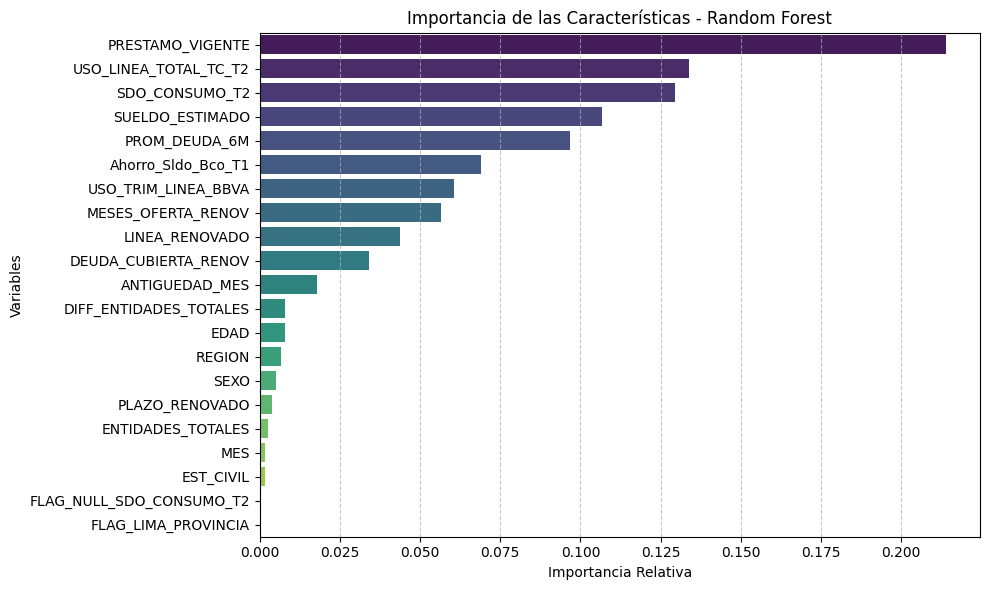

In [115]:
#GRAFICA DE CARACTERISTICAS MAS IMPORTANTES PARA RANDOM FOREST

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Obtener la importancia de las variables
importances = model_rf_grid.feature_importances_
feature_names = X_train_u.columns

# 2. Crear un DataFrame para facilitar la graficación
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Configurar el estilo y crear la gráfica
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    hue='Feature',
    palette='viridis',
    legend=False
)

# 4. Añadir etiquetas y título
plt.title('Importancia de las Características - Random Forest')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variables')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#Se observa que PRESTAMO_VIGENTE, USO_LINEA_TOTAL y PROM_DEUDA_6M presentan las mayores importancias para clasificar un cliente.

### **Parametrizacion Tuning del Modelo - XGBoost**
Busqueda de mejores parametros para el modelo XGBoost con el método:
*  GridSearchCV

#### XGBoost GridSearchCV
* Dataset undersampling: X_train_u, y_train_u
* cv: 3 fold cross-validation
* n_jobs: -1 para usar todos los procesadores computacionales disponibles

In [116]:
'''
xg = xgb.XGBClassifier(
    random_state=123
)

param_grid = {
    'max_depth': [3,4, 5, 7],
    'learning_rate': [0.1, 0.01, 0.05],
    'n_estimators': [10,50,100, 200],
    'subsample': [0.5,0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xg,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    scoring='recall'
)

grid_search_xg_model = grid_search.fit(X_train_u, y_train_u)
'''

"\nxg = xgb.XGBClassifier(\n    random_state=123\n)\n\nparam_grid = {\n    'max_depth': [3,4, 5, 7],\n    'learning_rate': [0.1, 0.01, 0.05],\n    'n_estimators': [10,50,100, 200],\n    'subsample': [0.5,0.8, 1.0]\n}\n\ngrid_search = GridSearchCV(\n    estimator=xg,\n    param_grid=param_grid,\n    cv=3,\n    n_jobs=-1,\n    scoring='recall'\n)\n\ngrid_search_xg_model = grid_search.fit(X_train_u, y_train_u)\n"

In [117]:
#Impresion de Resultados de Parametrizacion GridSearchCV
#print(f'Mejores Parametros:\n{grid_search_xg_model.best_params_}\n\nMejor Resultado Recall:\n{grid_search_xg_model.best_score_}')

In [118]:
#Ejemplo de resultado de gridsearchCV para ejecion de modelo con parametros manual
#{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 10, 'subsample': 1.0}
model_xg_grid= xgb.XGBClassifier(random_state=123,n_estimators = 10, max_depth = 3, learning_rate=0.01,subsample = 1.0)

#Modelado con Parametros de GridSeachCV

#model_xg_grid = grid_search.best_estimator_
model_xg_grid.fit(X_train_u,y_train_u)
y_pred_xg_grid = model_xg_grid.predict(X_test)

In [119]:
accuracy_xg_grid=accuracy_score(y_test,y_pred_xg_grid)
precision_xg_grid=precision_score(y_test,y_pred_xg_grid)
recall_xg_grid=recall_score(y_test,y_pred_xg_grid)
f1_xg_grid=f1_score(y_test,y_pred_xg_grid)
confussion_matrix_xg_grid=confusion_matrix(y_test,y_pred_xg_grid)
classification_report_xg_grid=classification_report(y_test,y_pred_xg_grid,digits = 3)

print(f'Resultados del modelo Random Forest (TUNNING) con dataset Undersampling')
print(f'\nAcurracy dataset TEST:\t{accuracy_xg_grid:0.4f}')
print(f'\nPrecision dataset TEST:\t{precision_xg_grid:0.4f}')
print(f'\nRecall dataset TEST:\t{recall_xg_grid:0.4f}')
print(f'\nF1 dataset TEST:\t{f1_xg_grid:0.4f}')
print(f'\nReporte de confusion_matrix:\n{confussion_matrix_xg_grid}')
print(f'\nReporte de classification:\n{classification_report_xg_grid}')

Resultados del modelo Random Forest (TUNNING) con dataset Undersampling

Acurracy dataset TEST:	0.3001

Precision dataset TEST:	0.0475

Recall dataset TEST:	0.8721

F1 dataset TEST:	0.0901

Reporte de confusion_matrix:
[[ 4649 12167]
 [   89   607]]

Reporte de classification:
              precision    recall  f1-score   support

           0      0.981     0.276     0.431     16816
           1      0.048     0.872     0.090       696

    accuracy                          0.300     17512
   macro avg      0.514     0.574     0.261     17512
weighted avg      0.944     0.300     0.418     17512



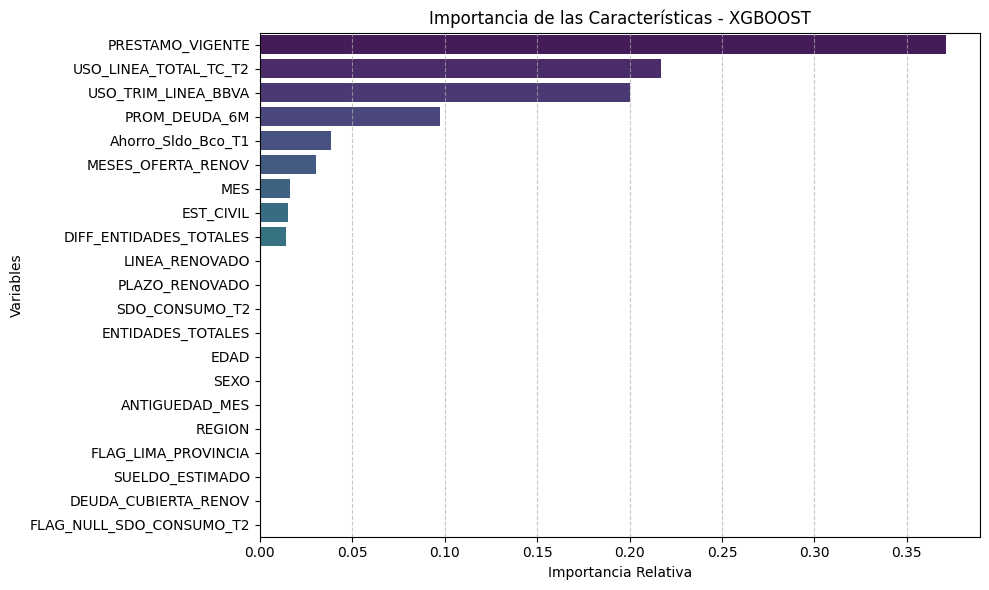

In [120]:
#GRAFICA DE CARACTERISTICAS MAS IMPORTANTES PARA XGBOOST
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Obtener la importancia de las variables
importances = model_xg_grid.feature_importances_
feature_names = X_train_u.columns

# 2. Crear un DataFrame para facilitar la graficación
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Configurar el estilo y crear la gráfica
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    hue='Feature',
    palette='viridis',
    legend=False
)

# 4. Añadir etiquetas y título
plt.title('Importancia de las Características - XGBOOST')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variables')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#Se observa que PRESTAMO_VIGENTE, USO_LINEA_TOTAL y PROM_DEUDA_6M presentan las mayores importancias para clasificar un cliente.

---
## **PARTE IV - DESPLIEGUE DEL MODELO MAS IMPORTANTE**
---

### Extraccion de datos Dummy

In [121]:
#Extraccion de muestras dummys para predicciones en modelos
num_casos=50

results_df = X_test.copy()
results_df['Real'] = y_test
results_df['Prediccion'] = y_pred_rf_grid

exitos_negativos = results_df[(results_df['Real'] == 0) & (results_df['Prediccion'] == 0)]
exitos_positivos = results_df[(results_df['Real'] == 1) & (results_df['Prediccion'] == 1)]

df_dummy_exitos_negativos = exitos_negativos.sample(n=num_casos, random_state=123) if len(exitos_negativos) >= num_casos else exitos_negativos.head(num_casos)
df_dummy_exitos_positivos = exitos_positivos.sample(n=num_casos, random_state=123) if len(exitos_positivos) >= num_casos else exitos_positivos.head(num_casos)


print(f'Muestra de {num_casos} casos de éxito (Predicción Correcta de casos Negativos):')
#display(df_dummy_exitos_negativos)
print(f'\nMuestra de {num_casos} casos de éxito (Predicción Correcta de casos Positivos):')
#display(df_dummy_exitos_positivos)

Muestra de 50 casos de éxito (Predicción Correcta de casos Negativos):

Muestra de 50 casos de éxito (Predicción Correcta de casos Positivos):


In [122]:
#Extraccion de TARGET del dataframe Dummy de casos de exito
X_dummy_exito_negativo = df_dummy_exitos_negativos.drop(['Real', 'Prediccion'], axis=1)
X_dummy_exito_positivo = df_dummy_exitos_positivos.drop(['Real', 'Prediccion'], axis=1)

####Predicciones con datos dummys

In [123]:
#Prediccion de Dummy con Target Exitoso Positivo y Negativo con Random Forest
print(f'Prediccion de {num_casos} casos de exito negativo con modelo Random Forest')
y_proba_rf = model_rf_grid.predict_proba(X_dummy_exito_negativo)[:, 1]
print(f'Resultados de probabilidades con random forest:\n{y_proba_rf}')
display(model_rf_grid.predict(X_dummy_exito_negativo))
print(f'\nPrediccion de {num_casos} casos de exito Positivo con modelo Random Forest')
display(model_rf_grid.predict(X_dummy_exito_positivo))
y_proba_rf = model_rf_grid.predict_proba(X_dummy_exito_negativo)[:, 1]
print(f'Resultados de probabilidades con random forest:\n{y_proba_rf}')

Prediccion de 50 casos de exito negativo con modelo Random Forest
Resultados de probabilidades con random forest:
[0.40779562 0.46304069 0.3859506  0.11133767 0.46643976 0.26451271
 0.26706755 0.49363766 0.34619072 0.45483293 0.46972817 0.35801983
 0.32159414 0.41462379 0.26226815 0.45559727 0.34625376 0.46972817
 0.4715635  0.29637927 0.43779237 0.34822104 0.39594923 0.38640271
 0.46643976 0.3701475  0.44220353 0.25656091 0.28893655 0.46643976
 0.41651765 0.43660091 0.42354938 0.4178292  0.46972817 0.46643976
 0.39494268 0.27798949 0.49991305 0.46972817 0.32268742 0.44220353
 0.14381452 0.34477452 0.22458866 0.39358479 0.46304069 0.46643976
 0.45051267 0.49524506]


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0])


Prediccion de 50 casos de exito Positivo con modelo Random Forest


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1])

Resultados de probabilidades con random forest:
[0.40779562 0.46304069 0.3859506  0.11133767 0.46643976 0.26451271
 0.26706755 0.49363766 0.34619072 0.45483293 0.46972817 0.35801983
 0.32159414 0.41462379 0.26226815 0.45559727 0.34625376 0.46972817
 0.4715635  0.29637927 0.43779237 0.34822104 0.39594923 0.38640271
 0.46643976 0.3701475  0.44220353 0.25656091 0.28893655 0.46643976
 0.41651765 0.43660091 0.42354938 0.4178292  0.46972817 0.46643976
 0.39494268 0.27798949 0.49991305 0.46972817 0.32268742 0.44220353
 0.14381452 0.34477452 0.22458866 0.39358479 0.46304069 0.46643976
 0.45051267 0.49524506]


In [124]:
#Prediccion de Dummy con Target Exitoso Positivo y Negativocon XGBoost

print(f'Prediccion de {num_casos} casos de exito negativo con modelo XGBoost')
display(model_xg_grid.predict(X_dummy_exito_negativo))
y_proba_xg = model_xg_grid.predict_proba(X_dummy_exito_negativo)[:, 1]
print(f'Resultados de probabilidades con xgboost:\n{y_proba_xg}')
print(f'\nPrediccion de {num_casos} casos de exito Positivo con modelo XGBoost')
display(model_xg_grid.predict(X_dummy_exito_positivo))
y_proba_xg = model_xg_grid.predict_proba(X_dummy_exito_positivo)[:, 1]
print(f'Resultados de probabilidades con xgboost:\n{y_proba_xg}')

Prediccion de 50 casos de exito negativo con modelo XGBoost


array([1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1])

Resultados de probabilidades con xgboost:
[0.5020236  0.5020236  0.5020236  0.46363625 0.5020236  0.46363625
 0.48749334 0.48749334 0.5020236  0.48749334 0.5020236  0.5066016
 0.5020236  0.46363625 0.46363625 0.5020236  0.48749334 0.5020236
 0.5020236  0.48749334 0.5020236  0.48749334 0.5020236  0.48749334
 0.5020236  0.5020236  0.48749334 0.46363625 0.46363625 0.5020236
 0.48749334 0.5020236  0.5020236  0.5020236  0.5020236  0.5020236
 0.48749334 0.46363625 0.5020236  0.5020236  0.48749334 0.48749334
 0.46363625 0.46363625 0.46363625 0.48749334 0.5020236  0.5020236
 0.46363625 0.5020236 ]

Prediccion de 50 casos de exito Positivo con modelo XGBoost


array([1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1])

Resultados de probabilidades con xgboost:
[0.5020236  0.5020236  0.5020236  0.48749334 0.5168921  0.5168921
 0.5168921  0.5168921  0.5020236  0.5020236  0.5020236  0.5020236
 0.5022779  0.5020236  0.49068263 0.5020236  0.5020236  0.5171461
 0.5020236  0.5020236  0.5020236  0.5020236  0.5020236  0.5186132
 0.5020236  0.5020236  0.5020236  0.5171461  0.5020236  0.5020236
 0.5020236  0.5020236  0.515491   0.48749334 0.5168921  0.5020236
 0.5020236  0.5020236  0.5186132  0.5020236  0.5186132  0.5020236
 0.5168921  0.5020236  0.5186132  0.5186132  0.5020236  0.5020236
 0.5020236  0.5020236 ]


####Exportacion de los modelos

In [125]:
import pickle
# Modelo Random Forest
# Guardar el modelo Random Forest en un archivo con pickle
with open('model_rf_renovacion.model', 'wb') as f:
    pickle.dump(model_rf_grid, f)

# Cargar el modelo Random Forest desde el archivo con pickle
with open('model_rf_renovacion.model', 'rb') as f:
    loaded_model = pickle.load(f)

# Modelo XGBoost
# Guardar el modelo XGBoost en un archivo con pickle
with open('model_xg_renovacion.model', 'wb') as f:
    pickle.dump(model_xg_grid, f)

# Cargar el modelo XGBoost desde el archivo con pickle
with open('model_xg_renovacion.model', 'rb') as f:
    loaded_model = pickle.load(f)

###Observaciones Finales de los modelos
* Random Forest:
   * Modelo más "seguro" siempre y cuando el banco decida "No molestar a nadie que no vaya a comprar".
   * Es más "robusto" porque sus probabilidades suelen ser más extremas (votos de muchos árboles).
* XGBoost:
   * Modelo más "ambicioso". siempre y cuando el banco decida "Llamar a todo el que respire con tal de no perder una venta".
   * Modelo que opera en la "zona de incertidumbre" (cerca del 0.50) por efecto secundario del Undersampling dado qué el modelo aprendió que el éxito es tan común como el fracaso, por lo que ante la duda, sitúa a casi todos los clientes en la frontera del 0.5.
   * Debido al balanceo, las probabilidades están concentradas en el centro.